# ScienceQA Visual Exploration

Standalone notebook for the **Pixels to Predictions**.
No GPU or model required — pure pandas + matplotlib analysis.

**Splits covered:** train (3,109) · val (1,048) · test (1,008) · sample submission (1,008)

**Sections**
1. Setup & Data Loading
2. Dataset Overview
3. Answer Distribution & Position Bias
4. Question Structure
5. Taxonomic Structure (Subject / Topic / Category / Skill / Grade)
6. Context Fields (hint & lecture)
7. Cross-Split Consistency
8. Summary Metrics Export
9. Context Ablation Plots
10. Ablation Studies Plot


## 1. Setup & Data Loading

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path

matplotlib.rcParams.update({
    "figure.dpi":        130,
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "axes.axisbelow":    True,
})

# Consistent colour palette used throughout
SUBJ_PAL = {
    "natural science":  "#4C72B0",
    "social science":   "#DD8452",
    "language science": "#55A868",
}
SPLIT_PAL = {"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"}

print("Imports OK.")


Imports OK.


In [ ]:
RUN_ID = "visual_exploration"
SUB_RUN_ID = ""  # can also be blank

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR_PATH = '/content/drive/MyDrive/Colab Notebooks/' + RUN_ID + '/'
DRIVE_DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/pixels-to-predictions.zip'

# Paths — adjust to Colab layout

# Local path for faster access
LOCAL_DATA_DIR = Path("/content/data")

# Do not recopy if data already exists
if not os.path.exists(LOCAL_DATA_DIR):
    # Ensure local data directory exists
    LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
    # Copy data from Drive to local disk
    print(f"Copying data from {DRIVE_DATA_PATH} to disk...")
    !cp -r "{DRIVE_DATA_PATH}" "."
    !unzip -q "pixels-to-predictions.zip" -d "{LOCAL_DATA_DIR}"
    print("Data copy complete.")

# Use the local data directory for the rest of the notebook
DATA_DIR = LOCAL_DATA_DIR / Path("pixels-to-predictions/")
print(f'All data present at: {DATA_DIR}')

OUT_DIR  = Path(DRIVE_DIR_PATH)      # where to save PNGs and metrics JSON
print(f'All output present at: {OUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All data present at: /content/data/pixels-to-predictions
All output present at: /content/drive/MyDrive/Colab Notebooks/data_exploration


In [ ]:
# ── Load CSVs ─────────────────────────────────────────────────────────────────
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")
sub_df   = pd.read_csv(DATA_DIR / "sample_submission.csv")

# Parse choices JSON string → Python list
for df in [train_df, val_df, test_df]:
    df["choices_parsed"] = df["choices"].apply(json.loads)

# Derived text-length features (used across multiple sections)
for df in [train_df, val_df, test_df]:
    df["q_len"]          = df["question"].str.len()
    df["hint_len"]        = df["hint"].fillna("").str.len()
    df["lecture_len"]     = df["lecture"].fillna("").str.len()
    df["choice_len_avg"]  = df["choices_parsed"].apply(
        lambda cs: float(np.mean([len(c) for c in cs]))
    )
    df["has_hint"]    = df["hint"].notna()    & (df["hint"].str.strip() != "")
    df["has_lecture"] = df["lecture"].notna() & (df["lecture"].str.strip() != "")

SPLITS = {"train": train_df, "val": val_df, "test": test_df}

print(f"train : {len(train_df):,} rows × {train_df.shape[1]} cols")
print(f"val   : {len(val_df):,} rows × {val_df.shape[1]} cols")
print(f"test  : {len(test_df):,} rows × {test_df.shape[1]} cols")
print(f"submission: {len(sub_df):,} rows × {sub_df.shape[1]} cols")


train : 3,109 rows × 22 cols
val   : 1,048 rows × 22 cols
test  : 1,008 rows × 20 cols
submission: 1,008 rows × 2 cols


## 2. Dataset Overview

In [ ]:
# ── 2a. Column presence and missing-value rates ───────────────────────────────
all_cols = list(dict.fromkeys(
    list(train_df.columns) + list(val_df.columns) + list(test_df.columns)
))
missing = {}
for col in all_cols:
    row = {}
    for name, df in SPLITS.items():
        if col in df.columns:
            pct = df[col].isna().mean() * 100
            row[name] = f"{pct:.1f}%" if pct > 0 else "0%"
        else:
            row[name] = "— (absent)"
    missing[col] = row

miss_df = pd.DataFrame(missing).T.rename_axis("column")
print("Missing-value rates by column and split:")
print(miss_df.to_string())


Missing-value rates by column and split:
                train    val        test
column                                  
id                 0%     0%          0%
image_path         0%     0%          0%
question           0%     0%          0%
choices            0%     0%          0%
num_choices        0%     0%          0%
answer             0%     0%  — (absent)
hint            23.3%  22.1%       21.2%
lecture         14.2%  12.7%       18.2%
solution        17.0%  16.4%  — (absent)
task               0%     0%          0%
grade              0%     0%          0%
subject            0%     0%          0%
topic              0%     0%          0%
category           0%     0%          0%
skill              0%     0%          0%
choices_parsed     0%     0%          0%
q_len              0%     0%          0%
hint_len           0%     0%          0%
lecture_len        0%     0%          0%
choice_len_avg     0%     0%          0%
has_hint           0%     0%          0%
has_lecture     

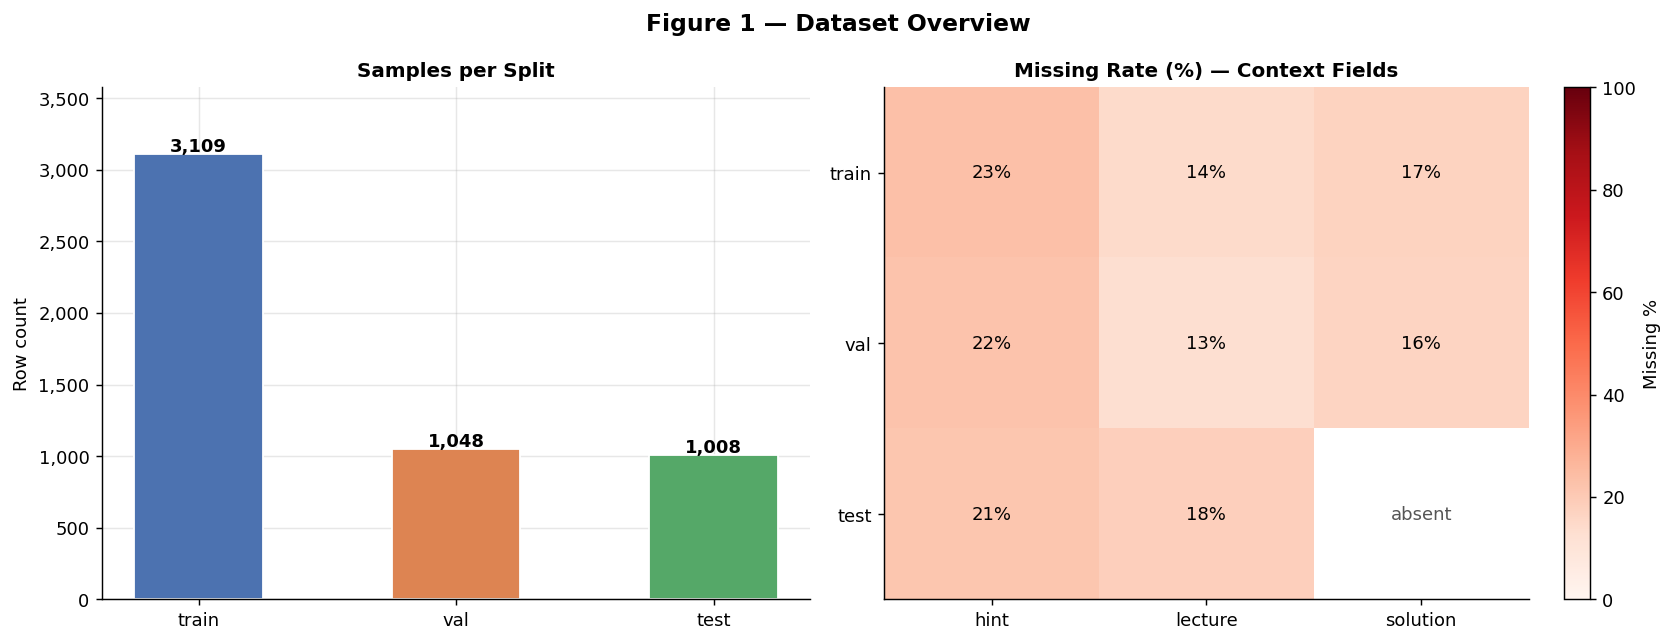

In [ ]:
# ── Figure 1: Split sizes + missing value heatmap ────────────────────────────
fig, (ax_size, ax_miss) = plt.subplots(1, 2, figsize=(13, 5))

# Left: split sizes
split_names  = ["train", "val", "test"]
split_counts = [len(train_df), len(val_df), len(test_df)]
bar_cols     = [SPLIT_PAL[s] for s in split_names]
bars = ax_size.bar(split_names, split_counts, color=bar_cols,
                   edgecolor="white", width=0.5)
for bar, cnt in zip(bars, split_counts):
    ax_size.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f"{cnt:,}", ha="center", fontsize=10, fontweight="bold")
ax_size.set_title("Samples per Split")
ax_size.set_ylabel("Row count")
ax_size.set_ylim(0, max(split_counts) * 1.15)
ax_size.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Right: missing % heatmap for contextual fields
ctx_cols = ["hint", "lecture", "solution"]
heat = np.array([
    [df[c].isna().mean() * 100 if c in df.columns else np.nan
     for c in ctx_cols]
    for df in [train_df, val_df, test_df]
])
im = ax_miss.imshow(heat, cmap="Reds", vmin=0, vmax=100, aspect="auto")
ax_miss.set_xticks(range(len(ctx_cols)))
ax_miss.set_xticklabels(ctx_cols)
ax_miss.set_yticks(range(3))
ax_miss.set_yticklabels(split_names)
ax_miss.set_title("Missing Rate (%) — Context Fields")
ax_miss.grid(False)
for r in range(3):
    for c, col in enumerate(ctx_cols):
        v = heat[r, c]
        if not np.isnan(v):
            tc = "white" if v > 55 else "black"
            lbl = f"{v:.0f}%" if v > 0 else "0%" if v == 0 else "N/A"
        else:
            lbl, tc = "absent", "#555"
        ax_miss.text(c, r, lbl, ha="center", va="center",
                     fontsize=10, color=tc)
plt.colorbar(im, ax=ax_miss, fraction=0.04).set_label("Missing %")

fig.suptitle("Figure 1 — Dataset Overview", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "fig1_overview.png", bbox_inches="tight")
plt.show()


## 3. Answer Distribution & Position Bias

The ground-truth answer index (0-indexed) shows a clear **position bias**: index 0
is the most common correct answer in the full dataset (36% in train), declining
sharply for higher indices. This is partly explained by the mix of 2-choice
questions (where only 0 and 1 exist) pulling up the early indices. The per-`num_choices`
breakdown below shows that within each choice-count group, the bias is much smaller.


In [ ]:
# ── 3a. Answer index distribution per split ───────────────────────────────────
print("Answer index distribution (% within split):")
for name, df in [("train", train_df), ("val", val_df)]:
    dist = (df["answer"].value_counts(normalize=True).sort_index() * 100).round(1)
    print(f"  {name}: {dict(dist)}")

print()
print("Answer index by num_choices (train) — within-group %:")
for nc in sorted(train_df["num_choices"].unique()):
    sub = train_df[train_df["num_choices"] == nc]
    dist = (sub["answer"].value_counts(normalize=True).sort_index() * 100).round(1)
    print(f"  {nc} choices (n={len(sub):,}): {dict(dist)}")


Answer index distribution (% within split):
  train: {0: np.float64(36.2), 1: np.float64(33.1), 2: np.float64(23.7), 3: np.float64(6.6), 4: np.float64(0.5)}
  val: {0: np.float64(33.1), 1: np.float64(35.5), 2: np.float64(23.6), 3: np.float64(7.2), 4: np.float64(0.7)}

Answer index by num_choices (train) — within-group %:
  2 choices (n=664): {0: np.float64(50.6), 1: np.float64(49.4)}
  3 choices (n=1,552): {0: np.float64(34.8), 1: np.float64(31.2), 2: np.float64(34.0)}
  4 choices (n=783): {0: np.float64(28.0), 1: np.float64(24.1), 2: np.float64(25.0), 3: np.float64(22.9)}
  5 choices (n=110): {0: np.float64(26.4), 1: np.float64(23.6), 2: np.float64(12.7), 3: np.float64(22.7), 4: np.float64(14.5)}


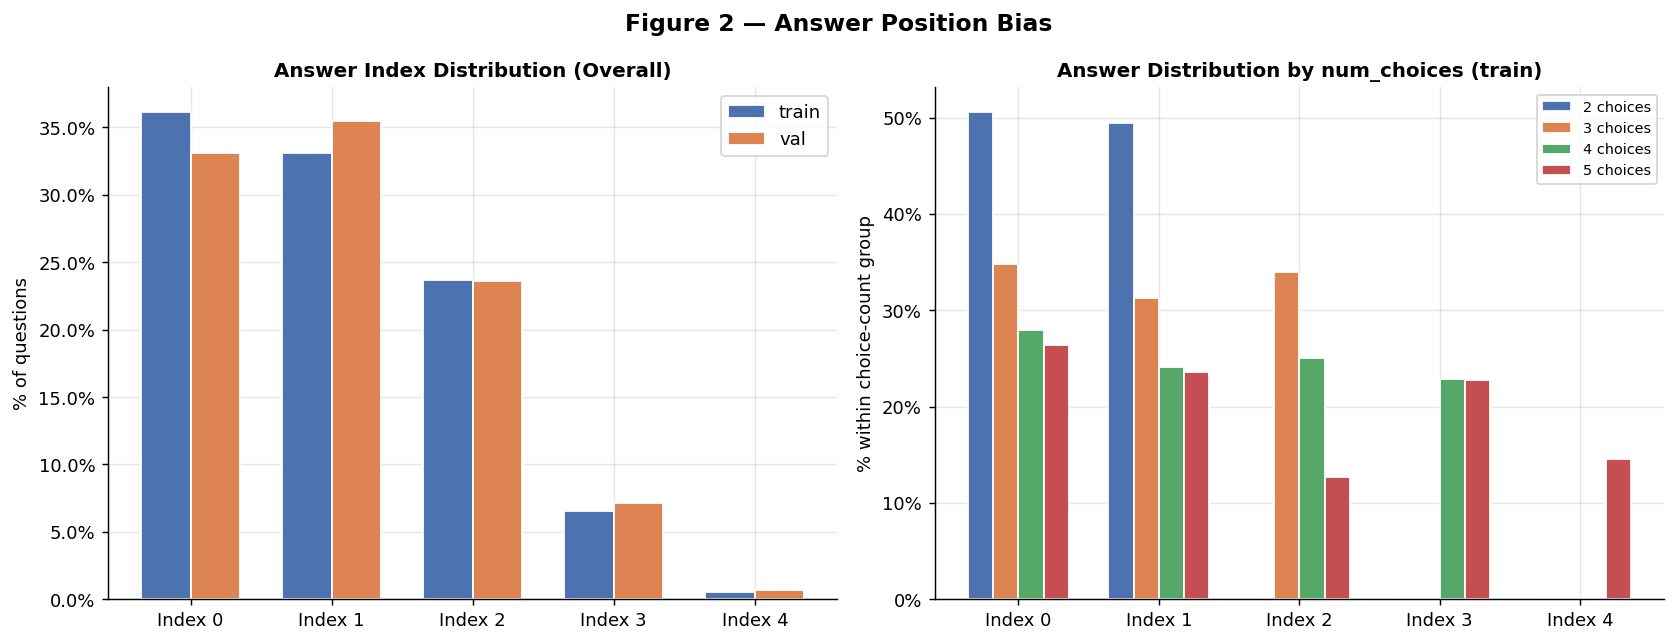

In [ ]:
# ── Figure 2: Answer position bias ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overall answer distribution by split (train + val only — test has no labels)
max_idx = 4
idxs    = list(range(max_idx + 1))
x       = np.arange(len(idxs))
width   = 0.35
for i, (name, df) in enumerate([("train", train_df), ("val", val_df)]):
    counts = [df["answer"].eq(idx).sum() / len(df) * 100 for idx in idxs]
    axes[0].bar(x + i * width, counts, width, label=name,
                color=SPLIT_PAL[name], edgecolor="white")
axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels([f"Index {i}" for i in idxs])
axes[0].set_ylabel("% of questions")
axes[0].set_title("Answer Index Distribution (Overall)")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

# Right: answer distribution stratified by num_choices (train only)
# Shows that within-group bias is much smaller than the aggregate bias.
nc_vals = sorted(train_df["num_choices"].unique())
nc_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bar_width = 0.18
all_positions = sorted(train_df["answer"].unique())
x2 = np.arange(len(all_positions))
for j, nc in enumerate(nc_vals):
    sub    = train_df[train_df["num_choices"] == nc]
    counts = [sub["answer"].eq(idx).sum() / len(sub) * 100
              if idx < nc else 0
              for idx in all_positions]
    axes[1].bar(x2 + j * bar_width, counts, bar_width,
                label=f"{nc} choices", color=nc_colors[j], edgecolor="white")
axes[1].set_xticks(x2 + bar_width * (len(nc_vals) - 1) / 2)
axes[1].set_xticklabels([f"Index {i}" for i in all_positions])
axes[1].set_ylabel("% within choice-count group")
axes[1].set_title("Answer Distribution by num_choices (train)")
axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

fig.suptitle("Figure 2 — Answer Position Bias", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "fig2_answer_bias.png", bbox_inches="tight")
plt.show()


## 4. Question Structure

In [ ]:
# ── 4a. num_choices distribution ─────────────────────────────────────────────
print("num_choices distribution:")
for name, df in SPLITS.items():
    dist = df["num_choices"].value_counts().sort_index()
    print(f"  {name}: {dict(dist)}")

print()
print("Question length summary (chars):")
print(pd.concat(
    [df["q_len"].describe().rename(n) for n, df in SPLITS.items()], axis=1
).round(1))

print()
print("Avg choice text length by num_choices (train):")
print(train_df.groupby("num_choices")["choice_len_avg"].mean().round(1))


num_choices distribution:
  train: {2: np.int64(664), 3: np.int64(1552), 4: np.int64(783), 5: np.int64(110)}
  val: {2: np.int64(244), 3: np.int64(508), 4: np.int64(252), 5: np.int64(44)}
  test: {2: np.int64(272), 3: np.int64(438), 4: np.int64(260), 5: np.int64(38)}

Question length summary (chars):
        train     val    test
count  3109.0  1048.0  1008.0
mean     70.7    72.4    71.0
std      34.1    33.6    32.2
min      14.0    17.0    17.0
25%      48.0    51.0    51.0
50%      62.0    62.0    62.0
75%      88.0   105.2    88.2
max     289.0   259.0   259.0

Avg choice text length by num_choices (train):
num_choices
2    48.7
3    30.9
4    19.4
5     3.0
Name: choice_len_avg, dtype: float64


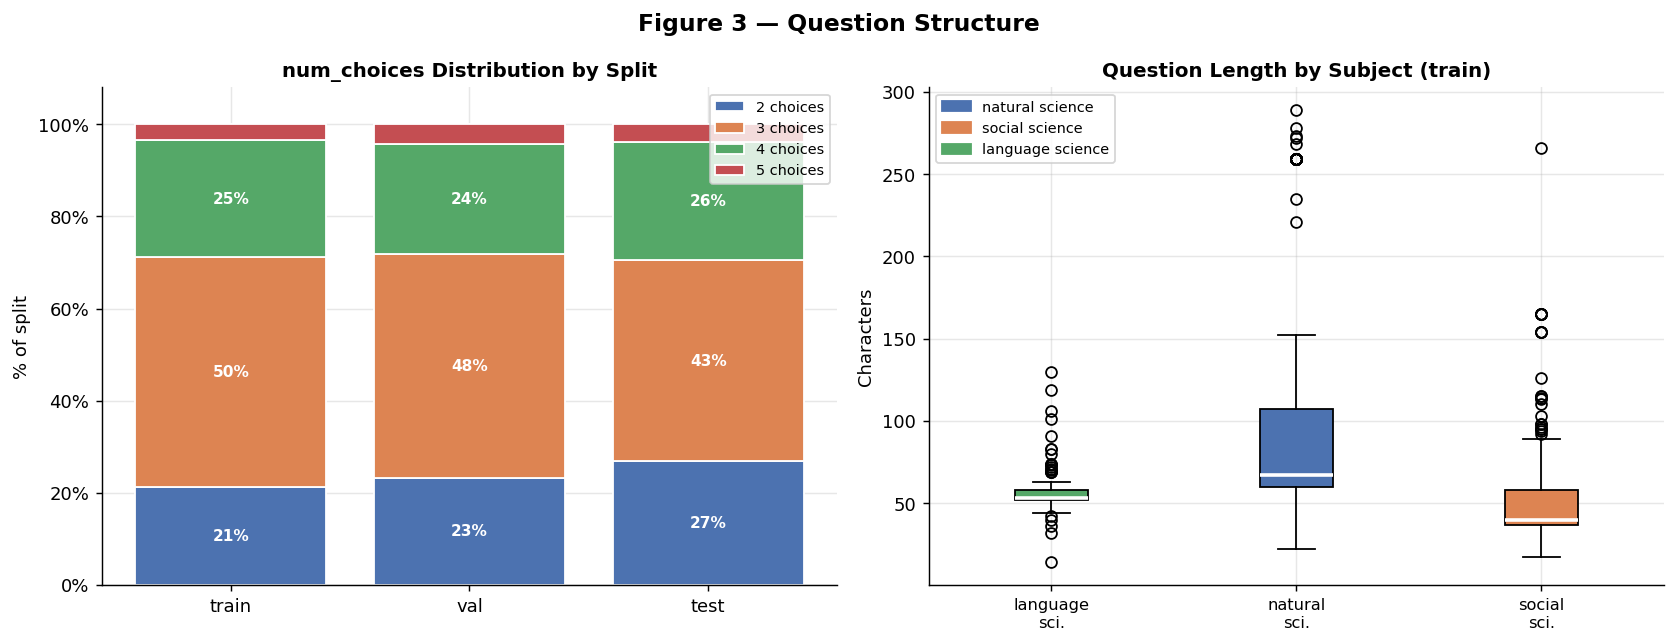

In [ ]:
# ── Figure 3: num_choices stacked bar + question length boxplots ──────────────
fig, (ax_nc, ax_ql) = plt.subplots(1, 2, figsize=(13, 5))

# Left: stacked bar — num_choices by split
nc_all  = sorted(train_df["num_choices"].unique())
nc_pal  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bottoms = np.zeros(3)
split_labels = list(SPLITS.keys())
for j, nc in enumerate(nc_all):
    vals = [df["num_choices"].eq(nc).sum() / len(df) * 100
            for df in SPLITS.values()]
    ax_nc.bar(split_labels, vals, bottom=bottoms,
              label=f"{nc} choices", color=nc_pal[j], edgecolor="white")
    # Annotate segments > 5%
    for k, (v, bot) in enumerate(zip(vals, bottoms)):
        if v > 5:
            ax_nc.text(k, bot + v / 2, f"{v:.0f}%",
                       ha="center", va="center", fontsize=8.5, color="white",
                       fontweight="bold")
    bottoms += np.array(vals)
ax_nc.set_ylabel("% of split")
ax_nc.set_title("num_choices Distribution by Split")
ax_nc.legend(fontsize=8, loc="upper right")
ax_nc.set_ylim(0, 108)
ax_nc.yaxis.set_major_formatter(mticker.PercentFormatter())

# Right: question length distribution by subject (train)
subj_list = sorted(train_df["subject"].unique())
data_by_subj = [train_df[train_df["subject"] == s]["q_len"].values for s in subj_list]
bp = ax_ql.boxplot(data_by_subj, vert=True, patch_artist=True,
                   medianprops={"color": "white", "linewidth": 2})
for patch, subj in zip(bp["boxes"], subj_list):
    patch.set_facecolor(SUBJ_PAL.get(subj, "#888"))
ax_ql.set_xticks(range(1, len(subj_list) + 1))
ax_ql.set_xticklabels(
    [s.replace(" science", "\nsci.") for s in subj_list], fontsize=9
)
ax_ql.set_ylabel("Characters")
ax_ql.set_title("Question Length by Subject (train)")
legend_patches = [mpatches.Patch(color=c, label=s)
                  for s, c in SUBJ_PAL.items() if s in subj_list]
ax_ql.legend(handles=legend_patches, fontsize=8)

fig.suptitle("Figure 3 — Question Structure", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "fig3_question_structure.png", bbox_inches="tight")
plt.show()


## 5. Taxonomic Structure

In [ ]:
# ── 5a. Subject distribution across splits ────────────────────────────────────
print("Subject distribution:")
print(pd.concat(
    [(df["subject"].value_counts(normalize=True)*100).rename(n)
     for n, df in SPLITS.items()], axis=1
).round(1))

print()
print("Topic distribution (train, top 10):")
print(train_df["topic"].value_counts().head(10))

print()
print("Unique counts (train):")
for col in ["topic", "category", "skill"]:
    print(f"  {col}: {train_df[col].nunique()} unique values")

print()
print("Grade distribution (train):")
print(train_df["grade"].value_counts().sort_index())


Subject distribution:
                  train   val  test
subject                            
natural science    72.8  74.1  73.2
social science     24.7  23.2  24.1
language science    2.5   2.7   2.7

Topic distribution (train, top 10):
topic
biology                              779
physics                              611
geography                            396
science-and-engineering-practices    393
chemistry                            281
earth-science                        182
us-history                           173
economics                            163
writing-strategies                    59
world-history                         30
Name: count, dtype: int64

Unique counts (train):
  topic: 14 unique values
  category: 55 unique values
  skill: 109 unique values

Grade distribution (train):
grade
grade1       5
grade12     21
grade2     115
grade3     289
grade4     484
grade5     354
grade6     611
grade7     545
grade8     685
Name: count, dtype: int64


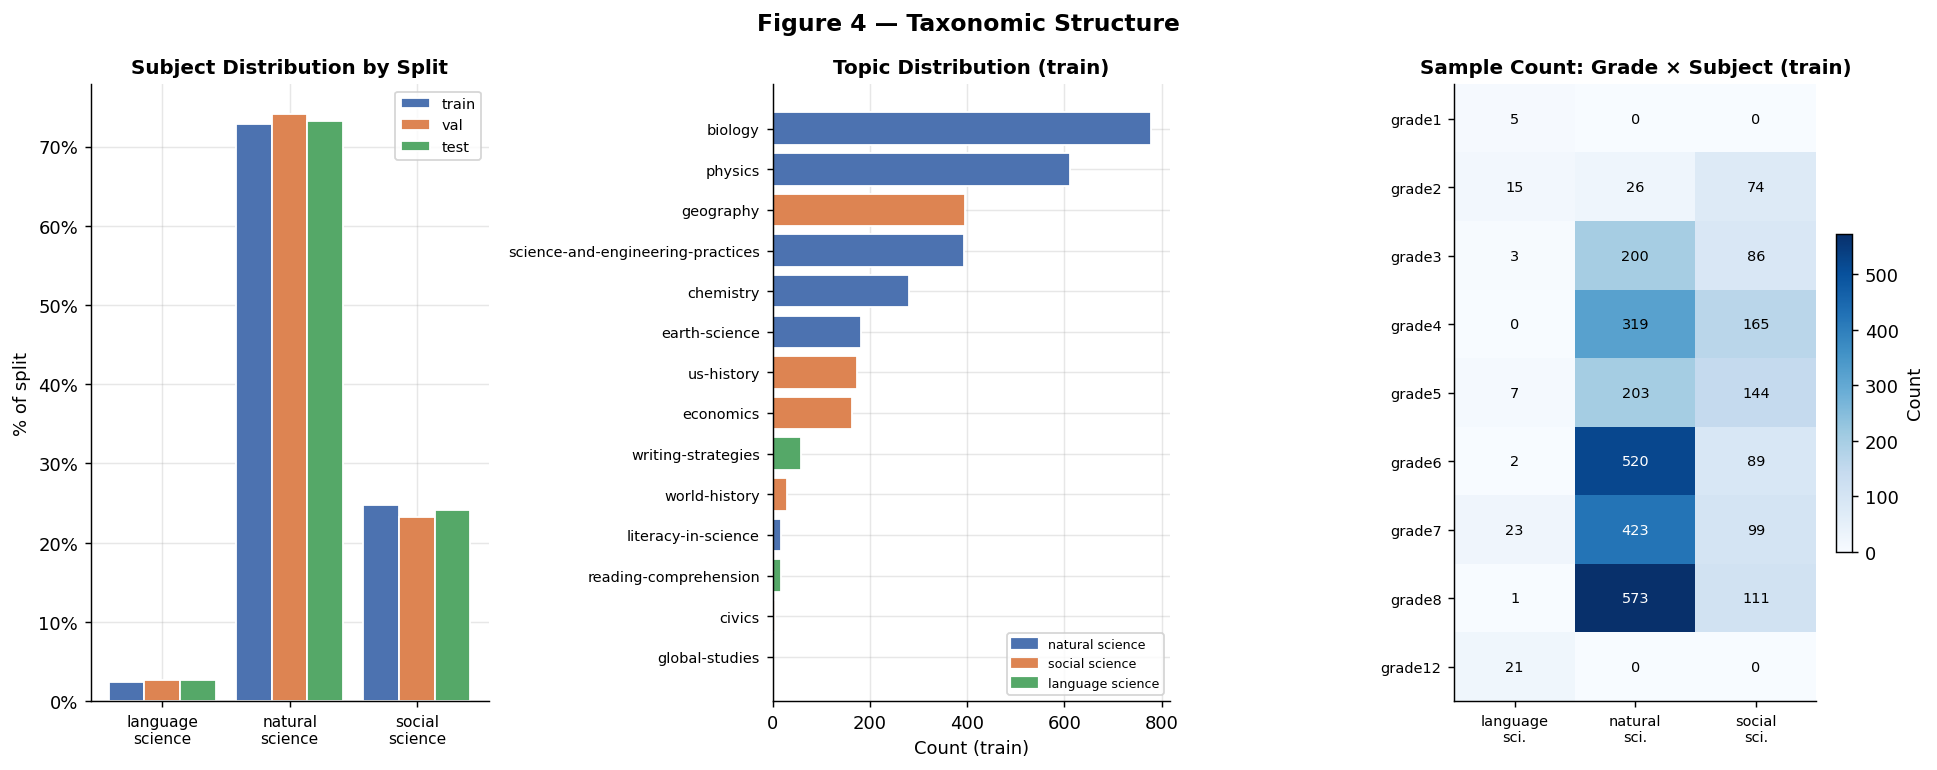

In [ ]:
# ── Figure 4: Subject + Topic + Grade ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Left: subject distribution grouped by split
subjs = sorted(train_df["subject"].unique())
x_s   = np.arange(len(subjs))
w     = 0.28
for i, (name, df) in enumerate(SPLITS.items()):
    vals = [df["subject"].eq(s).sum() / len(df) * 100 for s in subjs]
    axes[0].bar(x_s + i * w, vals, w, label=name,
                color=SPLIT_PAL[name], edgecolor="white")
axes[0].set_xticks(x_s + w)
axes[0].set_xticklabels([s.replace(" ", "\n") for s in subjs], fontsize=8.5)
axes[0].set_ylabel("% of split")
axes[0].set_title("Subject Distribution by Split")
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

# Centre: top 14 topics by train count, coloured by subject
topic_subject = (train_df.groupby("topic")["subject"]
                 .agg(lambda x: x.mode()[0]).to_dict())
topic_counts  = train_df["topic"].value_counts()
tc_colors     = [SUBJ_PAL.get(topic_subject.get(t, ""), "#888")
                 for t in topic_counts.index]
axes[1].barh(range(len(topic_counts)), topic_counts.values,
             color=tc_colors, edgecolor="white")
axes[1].set_yticks(range(len(topic_counts)))
axes[1].set_yticklabels(topic_counts.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Count (train)")
axes[1].set_title("Topic Distribution (train)")
axes[1].legend(handles=[mpatches.Patch(color=c, label=s)
                         for s, c in SUBJ_PAL.items()],
               fontsize=7, loc="lower right")

# Right: grade × subject heatmap (count)
grades_sorted = sorted(
    train_df["grade"].unique(),
    key=lambda g: int(g.replace("grade", "")) if g.replace("grade","").isdigit() else 99
)
grade_subj_ct = pd.crosstab(train_df["grade"], train_df["subject"])
grade_subj_ct = grade_subj_ct.reindex(grades_sorted)
heat_vals = grade_subj_ct.values.astype(float)
im = axes[2].imshow(heat_vals, cmap="Blues", aspect="auto")
axes[2].set_xticks(range(len(grade_subj_ct.columns)))
axes[2].set_xticklabels(
    [c.replace(" science", "\nsci.") for c in grade_subj_ct.columns], fontsize=8
)
axes[2].set_yticks(range(len(grades_sorted)))
axes[2].set_yticklabels(grades_sorted, fontsize=8)
axes[2].set_title("Sample Count: Grade × Subject (train)")
axes[2].grid(False)
for r in range(heat_vals.shape[0]):
    for c in range(heat_vals.shape[1]):
        v = int(heat_vals[r, c])
        tc = "white" if v > heat_vals.max() * 0.6 else "black"
        axes[2].text(c, r, str(v), ha="center", va="center",
                     fontsize=8, color=tc)
plt.colorbar(im, ax=axes[2], fraction=0.04).set_label("Count")

fig.suptitle("Figure 4 — Taxonomic Structure", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "fig4_taxonomy.png", bbox_inches="tight")
plt.show()


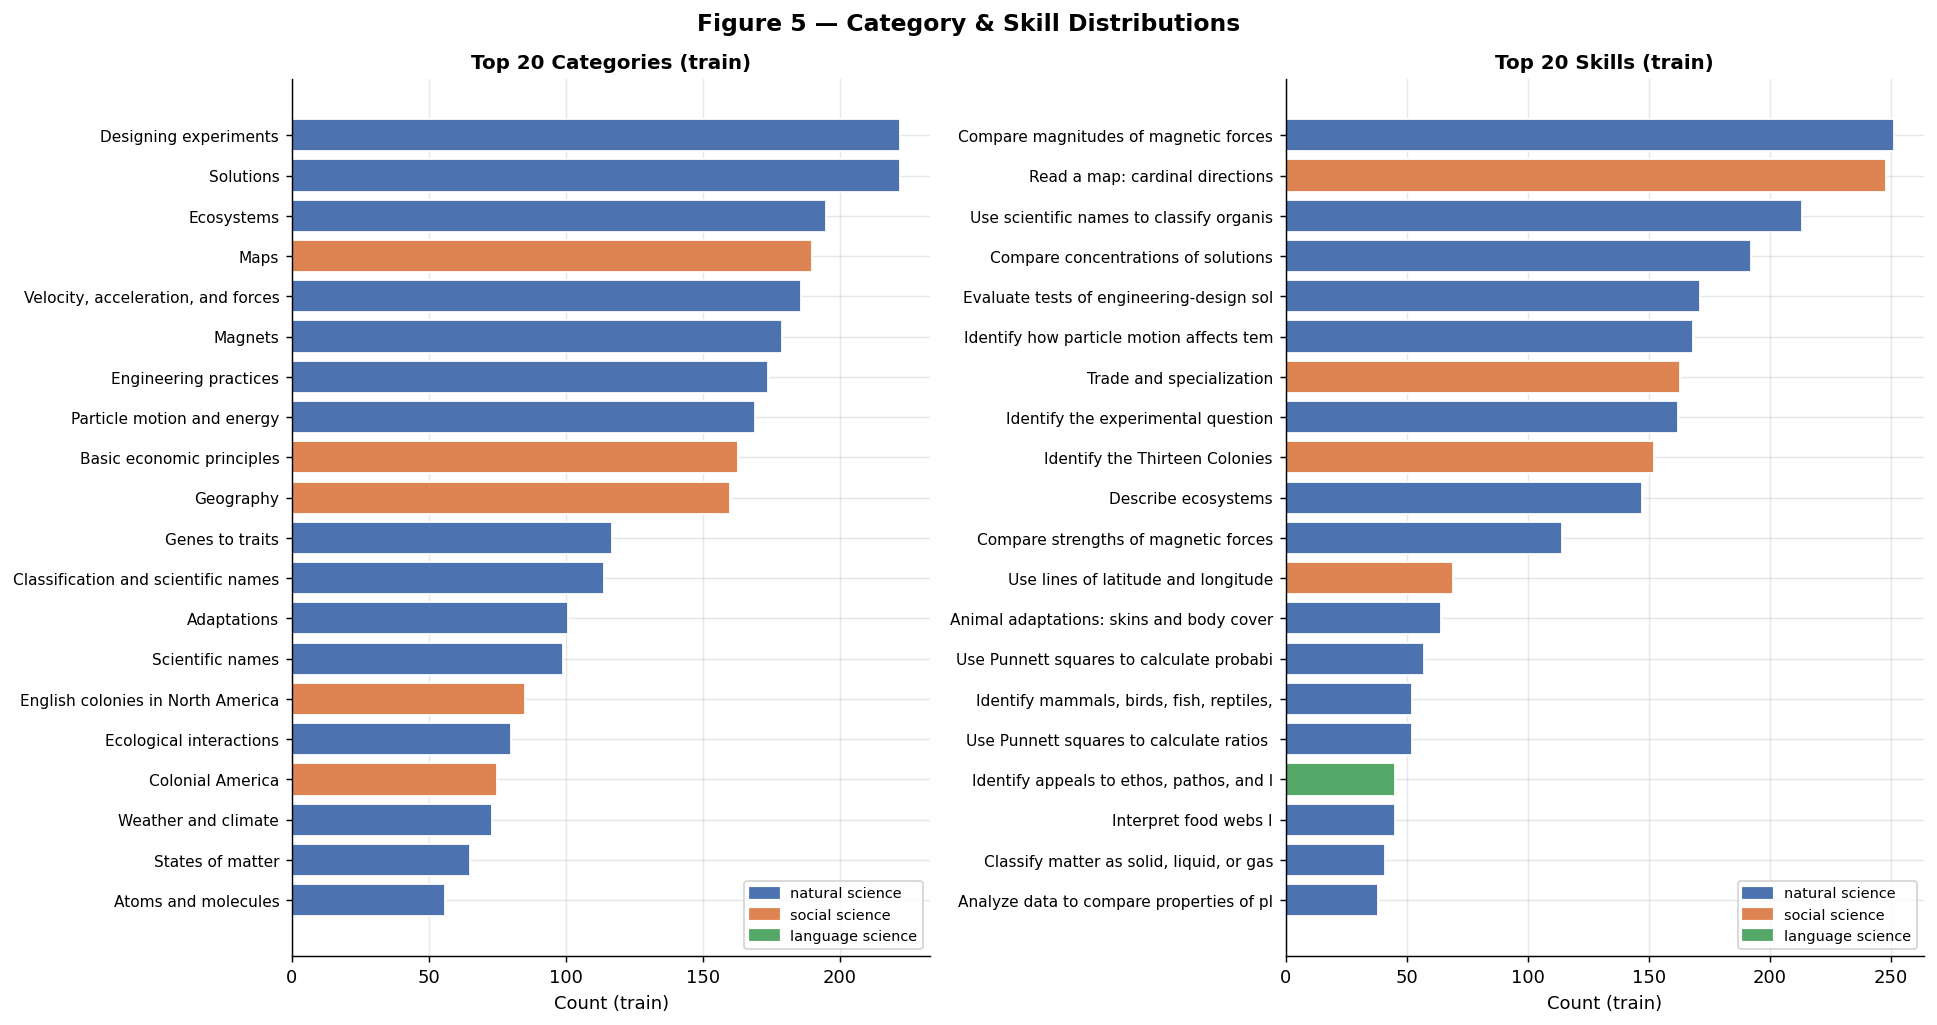

In [ ]:
# ── Figure 5: Top-20 categories + Top-20 skills ───────────────────────────────
fig, (ax_cat, ax_sk) = plt.subplots(1, 2, figsize=(15, 8))

# Helper: dominant subject colour for each group value
def group_color(df, group_col, val, default="#888"):
    sub = df[df[group_col] == val]["subject"].mode()
    return SUBJ_PAL.get(sub.iloc[0] if len(sub) else "", default)

# Left: top 20 categories
cat_counts = train_df["category"].value_counts().head(20)
cat_colors = [group_color(train_df, "category", c) for c in cat_counts.index]
ax_cat.barh(range(len(cat_counts)), cat_counts.values,
            color=cat_colors, edgecolor="white")
ax_cat.set_yticks(range(len(cat_counts)))
ax_cat.set_yticklabels([c[:36] for c in cat_counts.index], fontsize=8.5)
ax_cat.invert_yaxis()
ax_cat.set_xlabel("Count (train)")
ax_cat.set_title("Top 20 Categories (train)")
ax_cat.legend(handles=[mpatches.Patch(color=c, label=s)
                        for s, c in SUBJ_PAL.items()],
              fontsize=8, loc="lower right")

# Right: top 20 skills
sk_counts = train_df["skill"].value_counts().head(20)
sk_colors = [group_color(train_df, "skill", s) for s in sk_counts.index]
ax_sk.barh(range(len(sk_counts)), sk_counts.values,
           color=sk_colors, edgecolor="white")
ax_sk.set_yticks(range(len(sk_counts)))
ax_sk.set_yticklabels([s[:40] for s in sk_counts.index], fontsize=8.5)
ax_sk.invert_yaxis()
ax_sk.set_xlabel("Count (train)")
ax_sk.set_title("Top 20 Skills (train)")
ax_sk.legend(handles=[mpatches.Patch(color=c, label=s)
                       for s, c in SUBJ_PAL.items()],
             fontsize=8, loc="lower right")

fig.suptitle("Figure 5 — Category & Skill Distributions",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "fig5_category_skill.png", bbox_inches="tight")
plt.show()


## 6. Context Fields (hint & lecture)

- **`lecture`** is reused heavily — only 73 unique lectures across 3,109 training samples,
  with the most common one appearing 248 times. It provides background knowledge for a topic.
- **`hint`** is question-specific — 1,132 unique hints in train. It often contains a short
  passage the student must read before answering.
- **`solution`** is the gold-standard explanation (absent from test).


In [ ]:
# ── 6a. Context field presence and length statistics ─────────────────────────
print("Context field presence by split:")
for name, df in SPLITS.items():
    n = len(df)
    h  = df["has_hint"].sum()    if "has_hint"    in df.columns else 0
    l  = df["has_lecture"].sum() if "has_lecture" in df.columns else 0
    both    = (df["has_hint"] & df["has_lecture"]).sum() if "has_hint" in df.columns else 0
    neither = (~df["has_hint"] & ~df["has_lecture"]).sum() if "has_hint" in df.columns else 0
    print(f"  {name} (n={n:,}): hint={h} ({h/n*100:.0f}%)  "
          f"lecture={l} ({l/n*100:.0f}%)  "
          f"both={both}  neither={neither}")

print()
print("Lecture reuse (train): only",
      train_df["lecture"].nunique(), "unique values across",
      train_df["has_lecture"].sum(), "non-null rows")
print("Top 3 most-reused lecture snippets (first 80 chars + count):")
for txt, cnt in train_df["lecture"].value_counts().head(3).items():
    print(f"  ({cnt}×) {str(txt)[:80]}...")

print()
print("Hint length (chars, train, non-empty):")
print(train_df[train_df["hint_len"] > 0]["hint_len"].describe().round(1))
print()
print("Lecture length (chars, train, non-empty):")
print(train_df[train_df["lecture_len"] > 0]["lecture_len"].describe().round(1))


Context field presence by split:
  train (n=3,109): hint=2385 (77%)  lecture=2669 (86%)  both=2128  neither=183
  val (n=1,048): hint=816 (78%)  lecture=915 (87%)  both=722  neither=39
  test (n=1,008): hint=794 (79%)  lecture=825 (82%)  both=697  neither=86

Lecture reuse (train): only 73 unique values across 2669 non-null rows
Top 3 most-reused lecture snippets (first 80 chars + count):
  (248×) Maps have four cardinal directions, or main directions. Those directions are nor...
  (213×) Scientists use scientific names to identify organisms. Scientific names are made...
  (192×) A solution is made up of two or more substances that are completely mixed. In a ...

Hint length (chars, train, non-empty):
count    2385.0
mean      311.8
std       266.1
min        36.0
25%       123.0
50%       191.0
75%       455.0
max      1845.0
Name: hint_len, dtype: float64

Lecture length (chars, train, non-empty):
count    2669.0
mean      774.3
std       411.5
min       121.0
25%       443.0
50%    

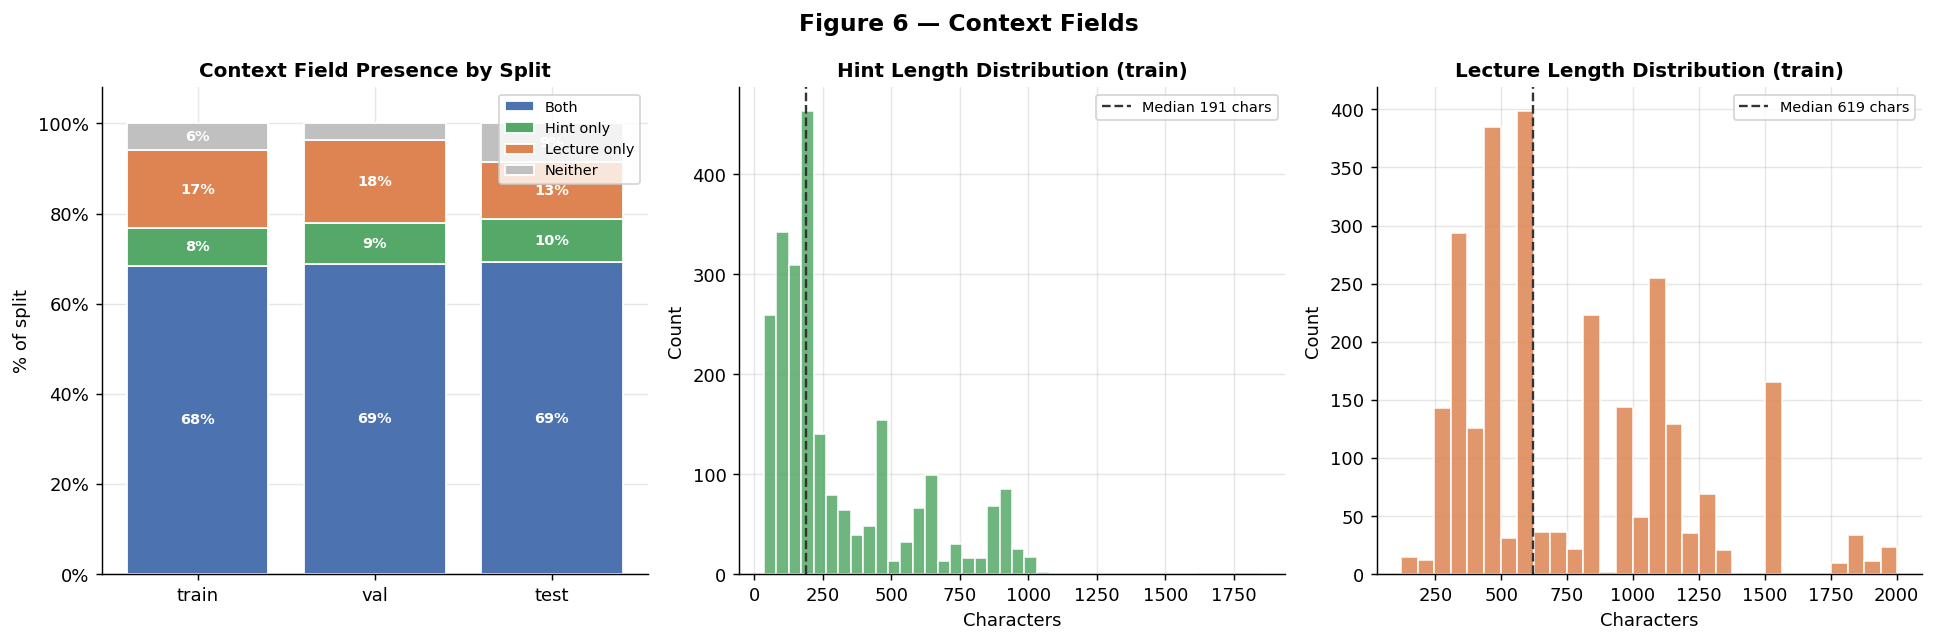

In [ ]:
# ── Figure 6: Context field presence + length distributions ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: context group stacked bars by split
ctx_labels = ["Both", "Hint only", "Lecture only", "Neither"]
ctx_colors = ["#4C72B0", "#55A868", "#DD8452", "#C0C0C0"]
split_names_all = list(SPLITS.keys())
bottoms = np.zeros(len(split_names_all))

def ctx_counts(df):
    h = df.get("has_hint",    pd.Series([False]*len(df)))
    l = df.get("has_lecture", pd.Series([False]*len(df)))
    n = len(df)
    return [
        (h & l).sum()  / n * 100,
        (h & ~l).sum() / n * 100,
        (~h & l).sum() / n * 100,
        (~h & ~l).sum()/ n * 100,
    ]

for j, (label, color) in enumerate(zip(ctx_labels, ctx_colors)):
    vals = [ctx_counts(df)[j] for df in SPLITS.values()]
    axes[0].bar(split_names_all, vals, bottom=bottoms,
                label=label, color=color, edgecolor="white")
    for k, (v, bot) in enumerate(zip(vals, bottoms)):
        if v > 4:
            axes[0].text(k, bot + v / 2, f"{v:.0f}%",
                         ha="center", va="center",
                         fontsize=8, color="white", fontweight="bold")
    bottoms += np.array(vals)
axes[0].set_ylabel("% of split")
axes[0].set_title("Context Field Presence by Split")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_ylim(0, 108)

# Centre: hint length histogram (train, non-empty)
hint_nonzero = train_df[train_df["hint_len"] > 0]["hint_len"]
axes[1].hist(hint_nonzero, bins=40, color="#55A868", edgecolor="white", alpha=0.85)
axes[1].axvline(hint_nonzero.median(), color="#333", linestyle="--",
                linewidth=1.3, label=f"Median {int(hint_nonzero.median())} chars")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")
axes[1].set_title("Hint Length Distribution (train)")
axes[1].legend(fontsize=8)

# Right: lecture length histogram (train, non-empty)
lect_nonzero = train_df[train_df["lecture_len"] > 0]["lecture_len"]
axes[2].hist(lect_nonzero, bins=30, color="#DD8452", edgecolor="white", alpha=0.85)
axes[2].axvline(lect_nonzero.median(), color="#333", linestyle="--",
                linewidth=1.3, label=f"Median {int(lect_nonzero.median())} chars")
axes[2].set_xlabel("Characters")
axes[2].set_ylabel("Count")
axes[2].set_title("Lecture Length Distribution (train)")
axes[2].legend(fontsize=8)

fig.suptitle("Figure 6 — Context Fields", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "fig6_context_fields.png", bbox_inches="tight")
plt.show()


## 7. Cross-Split Consistency

Checks whether question text, skills, and taxonomic labels are
consistent across train / val / test. Overlapping questions do not
constitute leakage because the *image* and *context* can differ, but
they are worth tracking.


In [ ]:
# ── 7a. Question text overlap ─────────────────────────────────────────────────
q_sets = {name: set(df["question"]) for name, df in SPLITS.items()}
print("Question text overlap (identical strings):")
pairs = [("train", "val"), ("train", "test"), ("val", "test")]
for a, b in pairs:
    overlap = len(q_sets[a] & q_sets[b])
    print(f"  {a} ∩ {b}: {overlap} shared questions"
          f" ({overlap/min(len(q_sets[a]),len(q_sets[b]))*100:.1f}% of smaller split)")

print()
print("Skill coverage across splits (unique skills):")
for name, df in SPLITS.items():
    print(f"  {name}: {df['skill'].nunique()} skills")
sk_train = set(train_df["skill"])
sk_val   = set(val_df["skill"])
sk_test  = set(test_df["skill"])
print(f"  val skills not in train  : {len(sk_val - sk_train)}")
print(f"  test skills not in train : {len(sk_test - sk_train)}")

print()
print("Subject composition consistency (should be ~stable across splits):")
subj_frac = pd.concat(
    [(df["subject"].value_counts(normalize=True)*100).rename(n)
     for n, df in SPLITS.items()], axis=1
).round(1)
print(subj_frac)


Question text overlap (identical strings):
  train ∩ val: 204 shared questions (40.4% of smaller split)
  train ∩ test: 199 shared questions (38.9% of smaller split)
  val ∩ test: 135 shared questions (26.7% of smaller split)

Skill coverage across splits (unique skills):
  train: 109 skills
  val: 79 skills
  test: 71 skills
  val skills not in train  : 15
  test skills not in train : 9

Subject composition consistency (should be ~stable across splits):
                  train   val  test
subject                            
natural science    72.8  74.1  73.2
social science     24.7  23.2  24.1
language science    2.5   2.7   2.7


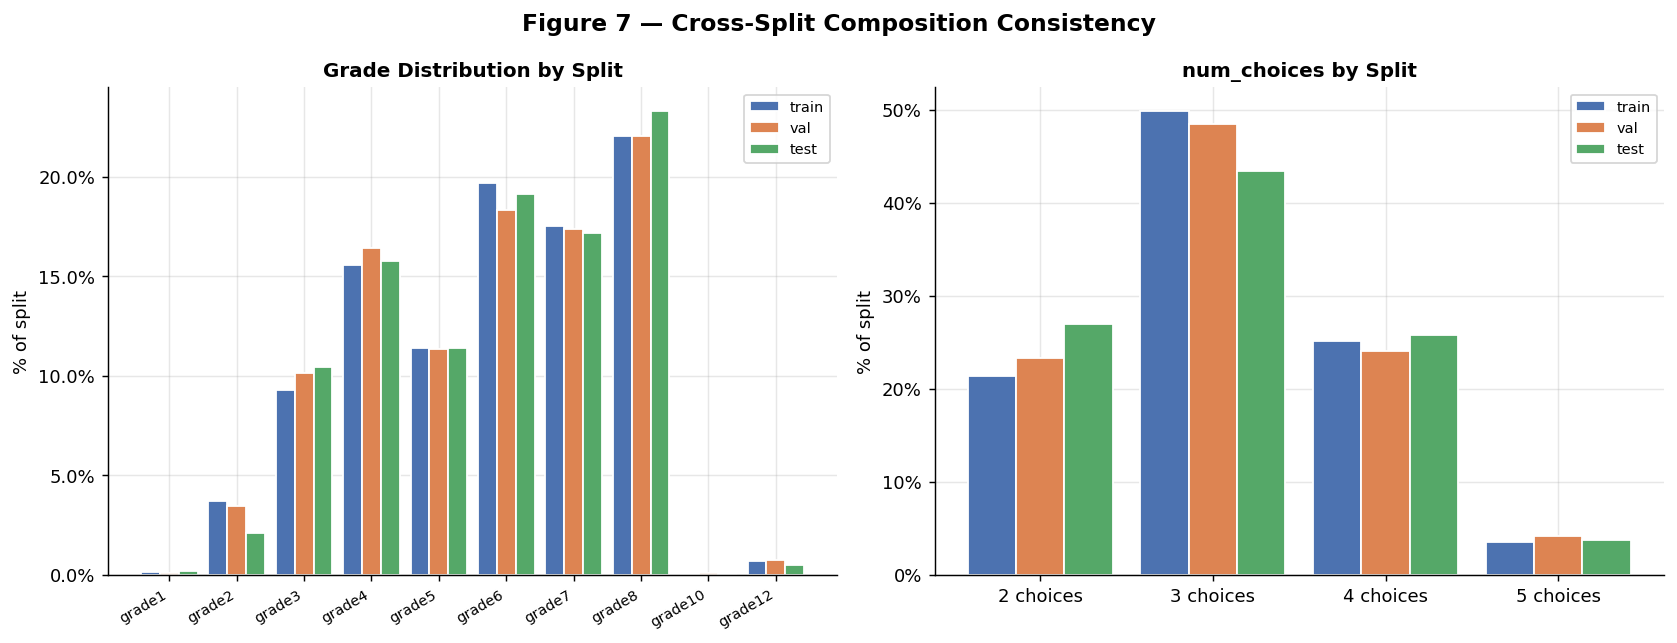

In [ ]:
# ── Figure 7: Cross-split composition comparison ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: grade distribution by split (normalised)
grades_s = sorted(
    set(train_df["grade"]) | set(val_df["grade"]) | set(test_df["grade"]),
    key=lambda g: int(g.replace("grade", "")) if g.replace("grade","").isdigit() else 99
)
x_g = np.arange(len(grades_s))
w_g = 0.28
for i, (name, df) in enumerate(SPLITS.items()):
    vals = [df["grade"].eq(g).sum() / len(df) * 100 for g in grades_s]
    axes[0].bar(x_g + i * w_g, vals, w_g, label=name,
                color=SPLIT_PAL[name], edgecolor="white")
axes[0].set_xticks(x_g + w_g)
axes[0].set_xticklabels(grades_s, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("% of split")
axes[0].set_title("Grade Distribution by Split")
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

# Right: num_choices comparison across splits
nc_all_vals = sorted(
    set(train_df["num_choices"]) | set(val_df["num_choices"]) | set(test_df["num_choices"])
)
x_nc = np.arange(len(nc_all_vals))
for i, (name, df) in enumerate(SPLITS.items()):
    vals = [df["num_choices"].eq(nc).sum() / len(df) * 100 for nc in nc_all_vals]
    axes[1].bar(x_nc + i * w_g, vals, w_g, label=name,
                color=SPLIT_PAL[name], edgecolor="white")
axes[1].set_xticks(x_nc + w_g)
axes[1].set_xticklabels([f"{nc} choices" for nc in nc_all_vals])
axes[1].set_ylabel("% of split")
axes[1].set_title("num_choices by Split")
axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

fig.suptitle("Figure 7 — Cross-Split Composition Consistency",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "fig7_cross_split.png", bbox_inches="tight")
plt.show()


## 8. Image Metrics

Samples up to **`IMG_SAMPLE_PER_SPLIT`** images from each split and measures
pixel-level properties using PIL. All paths are resolved relative to `DATA_DIR`
at runtime — cells will skip gracefully if images are not yet available.

Metrics collected per image:
- **Dimensions** — width × height in pixels
- **Aspect ratio** — width / height
- **File size** — on-disk bytes
- **Mean brightness** — average pixel intensity on the grayscale version (0–255)
- **Is grayscale** — True when per-channel std < 5 (effectively monochrome)
- **Mode** — PIL image mode (RGB, RGBA, L, etc.)


In [ ]:
# ── 8a. Sample images and compute per-image metrics ─────────────────────────
# IMG_SAMPLE_PER_SPLIT controls how many images are sampled from each split.
# Lower = faster; set to None to scan every image (slow for train).
IMG_SAMPLE_PER_SPLIT = 300

import os
from PIL import Image as PILImage

def collect_image_stats(df, split_name, data_dir, n_sample=None, seed=42):
    """
    Walk a sample of image_path entries in df, open each with PIL, and
    return a DataFrame of per-image metrics. Skips files that are absent.
    """
    rng    = np.random.default_rng(seed)
    rows   = df if n_sample is None else df.sample(
        n=min(n_sample, len(df)), random_state=seed
    )
    records = []
    missing = 0

    for _, row in rows.iterrows():
        fpath = Path(data_dir) / row["image_path"]
        if not fpath.exists():
            missing += 1
            continue
        try:
            img  = PILImage.open(fpath)
            w, h = img.size
            mode = img.mode
            size_bytes = fpath.stat().st_size

            # Brightness: mean pixel value on grayscale version
            gray = np.array(img.convert("L"), dtype=np.float32)
            brightness = float(gray.mean())

            # Grayscale check: if RGB std across channels < 5, effectively mono
            if img.mode in ("RGB", "RGBA"):
                arr = np.array(img.convert("RGB"), dtype=np.float32)
                channel_std = float(arr.std(axis=(0, 1)).mean())
                is_gray = channel_std < 5.0
            else:
                is_gray = True
                channel_std = 0.0

            records.append({
                "split":       split_name,
                "id":          row["id"],
                "subject":     row.get("subject", ""),
                "topic":       row.get("topic", ""),
                "width":       w,
                "height":      h,
                "aspect":      round(w / h, 4),
                "size_bytes":  size_bytes,
                "size_kb":     round(size_bytes / 1024, 2),
                "brightness":  round(brightness, 2),
                "channel_std": round(channel_std, 2),
                "is_gray":     is_gray,
                "mode":        mode,
            })
        except Exception as e:
            missing += 1

    result = pd.DataFrame(records)
    print(f"  {split_name}: {len(result)} images measured, {missing} skipped")
    return result


# Collect stats for all three splits
print(f"Sampling up to {IMG_SAMPLE_PER_SPLIT} images per split from {DATA_DIR}...")
img_frames = []
for name, df in SPLITS.items():
    frame = collect_image_stats(df, name, DATA_DIR, IMG_SAMPLE_PER_SPLIT)
    img_frames.append(frame)

img_df = pd.concat(img_frames, ignore_index=True)

if len(img_df) == 0:
    print("\nNo images found — check that DATA_DIR is set correctly.")
    print(f"Expected images at e.g.: {DATA_DIR / train_df['image_path'].iloc[0]}")
else:
    print(f"\nTotal images measured: {len(img_df):,}")
    print()
    print("── Dimension summary (pixels) ───────────────────────────────")
    print(img_df[["width", "height", "aspect"]].describe().round(1))
    print()
    print("── File size summary (KB) ───────────────────────────────────")
    print(img_df["size_kb"].describe().round(1))
    print()
    print("── Brightness summary (0–255) ───────────────────────────────")
    print(img_df["brightness"].describe().round(1))
    print()
    print("── Mode distribution ────────────────────────────────────────")
    print(img_df["mode"].value_counts())
    print()
    print("── Grayscale vs colour ──────────────────────────────────────")
    gray_ct = img_df["is_gray"].sum()
    print(f"  Grayscale : {gray_ct} ({gray_ct/len(img_df)*100:.1f}%)")
    print(f"  Colour    : {len(img_df)-gray_ct} ({(len(img_df)-gray_ct)/len(img_df)*100:.1f}%)")
    print()
    print("── Per-subject brightness mean ───────────────────────────────")
    print(img_df.groupby("subject")["brightness"].mean().round(1))


Sampling up to 300 images per split from /content/data/pixels-to-predictions...
  train: 300 images measured, 0 skipped
  val: 300 images measured, 0 skipped
  test: 300 images measured, 0 skipped

Total images measured: 900

── Dimension summary (pixels) ───────────────────────────────
       width  height  aspect
count  900.0   900.0   900.0
mean   428.1   275.3     1.9
std    186.0   127.4     1.4
min     68.0    80.0     0.4
25%    302.0   174.0     1.0
50%    378.0   237.0     1.3
75%    563.0   358.0     1.7
max    760.0   595.0     7.4

── File size summary (KB) ───────────────────────────────────
count    900.0
mean      68.7
std       72.7
min        1.1
25%       18.5
50%       46.1
75%       91.3
max      473.6
Name: size_kb, dtype: float64

── Brightness summary (0–255) ───────────────────────────────
count    900.0
mean     182.0
std       56.0
min       21.8
25%      131.1
50%      196.1
75%      232.7
max      250.7
Name: brightness, dtype: float64

── Mode distribution 

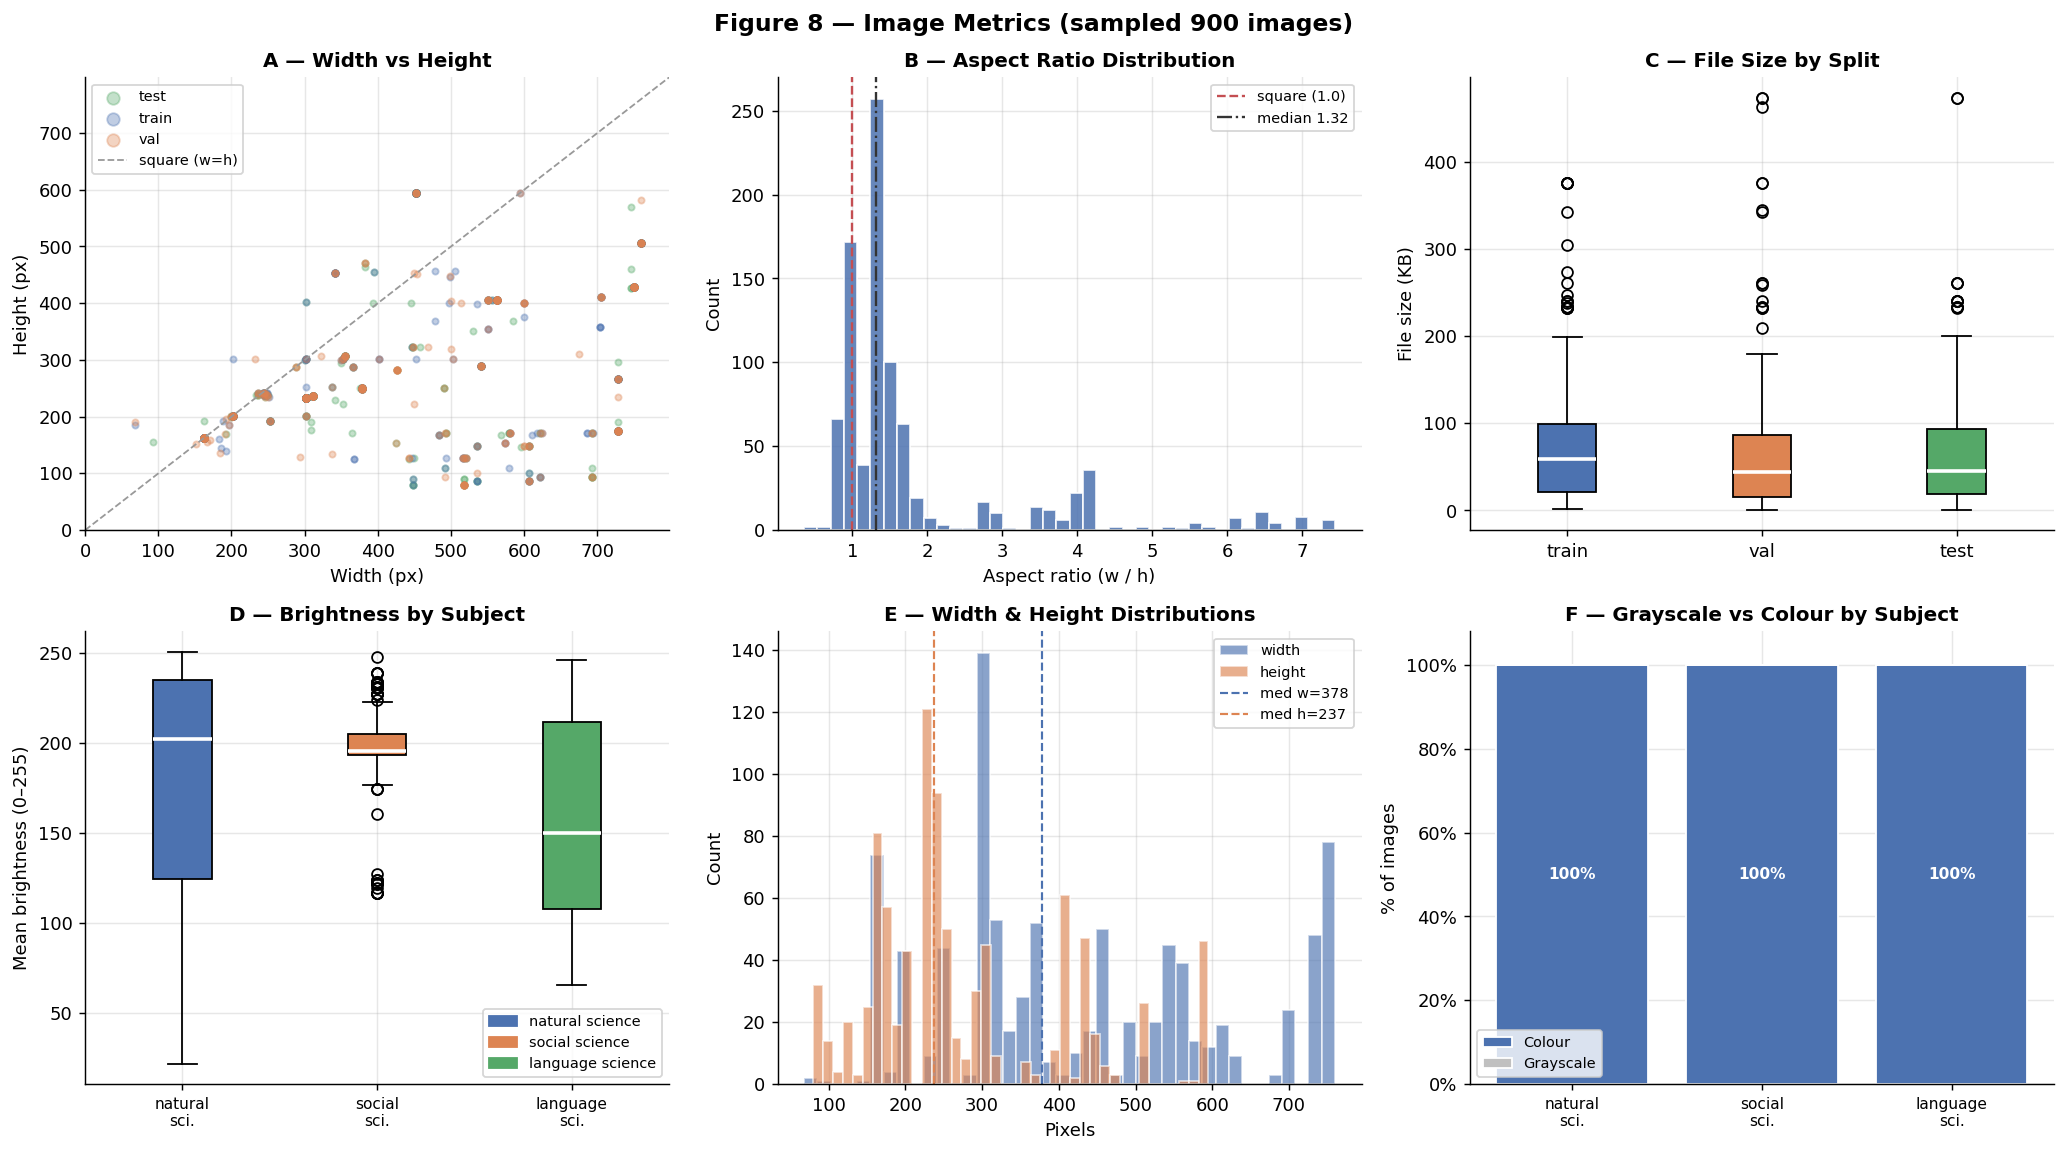

Figure 8 saved → fig8_image_metrics.png


In [ ]:
# ── 8b. Image metric plots (Figure 8) ────────────────────────────────────────
if len(img_df) == 0:
    print("No image data — skipping plots.")
else:
    fig8, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    # ── A: Width vs height scatter, coloured by split ─────────────────────────
    # Reveals whether images are consistently square, portrait, or landscape,
    # and whether any outlier dimensions exist in a particular split.
    for split_name, grp in img_df.groupby("split"):
        axes[0].scatter(
            grp["width"], grp["height"],
            alpha=0.35, s=12, label=split_name,
            color=SPLIT_PAL.get(split_name, "#888"),
        )
    # Diagonal = square images
    lim = max(img_df["width"].max(), img_df["height"].max()) * 1.05
    axes[0].plot([0, lim], [0, lim], "--", color="#999", linewidth=1,
                 label="square (w=h)")
    axes[0].set_xlim(0, lim)
    axes[0].set_ylim(0, lim)
    axes[0].set_xlabel("Width (px)")
    axes[0].set_ylabel("Height (px)")
    axes[0].set_title("A — Width vs Height")
    axes[0].legend(fontsize=8, markerscale=2)

    # ── B: Aspect ratio histogram ─────────────────────────────────────────────
    # Aspect ratio = width / height. 1.0 = square, >1 = landscape, <1 = portrait.
    axes[1].hist(img_df["aspect"], bins=40, color="#4C72B0",
                 edgecolor="white", alpha=0.85)
    axes[1].axvline(1.0, color="#C44E52", linestyle="--",
                    linewidth=1.3, label="square (1.0)")
    axes[1].axvline(img_df["aspect"].median(), color="#333",
                    linestyle="-.", linewidth=1.3,
                    label=f"median {img_df['aspect'].median():.2f}")
    axes[1].set_xlabel("Aspect ratio (w / h)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("B — Aspect Ratio Distribution")
    axes[1].legend(fontsize=8)

    # ── C: File size distribution by split ────────────────────────────────────
    # Larger files may take longer to load during training; an unusually wide
    # distribution signals inconsistent image quality or resolution.
    split_order = [s for s in ["train", "val", "test"] if s in img_df["split"].values]
    data_by_split = [img_df[img_df["split"] == s]["size_kb"].values for s in split_order]
    bp = axes[2].boxplot(
        data_by_split, vert=True, patch_artist=True,
        medianprops={"color": "white", "linewidth": 2},
    )
    for patch, sname in zip(bp["boxes"], split_order):
        patch.set_facecolor(SPLIT_PAL.get(sname, "#888"))
    axes[2].set_xticks(range(1, len(split_order) + 1))
    axes[2].set_xticklabels(split_order)
    axes[2].set_ylabel("File size (KB)")
    axes[2].set_title("C — File Size by Split")

    # ── D: Brightness distribution by subject ─────────────────────────────────
    # Brightness (mean grayscale intensity, 0–255). Science images with diagrams
    # on white backgrounds will skew bright; maps or photos will be darker.
    subj_present = [s for s in SUBJ_PAL if s in img_df["subject"].values]
    data_by_subj = [img_df[img_df["subject"] == s]["brightness"].values
                    for s in subj_present]
    bp2 = axes[3].boxplot(
        data_by_subj, vert=True, patch_artist=True,
        medianprops={"color": "white", "linewidth": 2},
    )
    for patch, subj in zip(bp2["boxes"], subj_present):
        patch.set_facecolor(SUBJ_PAL.get(subj, "#888"))
    axes[3].set_xticks(range(1, len(subj_present) + 1))
    axes[3].set_xticklabels(
        [s.replace(" science", "\nsci.") for s in subj_present], fontsize=8.5
    )
    axes[3].set_ylabel("Mean brightness (0–255)")
    axes[3].set_title("D — Brightness by Subject")
    axes[3].legend(
        handles=[mpatches.Patch(color=SUBJ_PAL[s], label=s)
                 for s in subj_present],
        fontsize=8,
    )

    # ── E: Width and height marginal distributions (overlaid histograms) ──────
    # Overlaying width and height on one axis shows whether most images
    # are square (distributions coincide) or systematically wider/taller.
    axes[4].hist(img_df["width"],  bins=40, alpha=0.65, label="width",
                 color="#4C72B0", edgecolor="white")
    axes[4].hist(img_df["height"], bins=40, alpha=0.65, label="height",
                 color="#DD8452", edgecolor="white")
    axes[4].axvline(img_df["width"].median(),  color="#4C72B0",
                    linestyle="--", linewidth=1.2,
                    label=f"med w={int(img_df['width'].median())}")
    axes[4].axvline(img_df["height"].median(), color="#DD8452",
                    linestyle="--", linewidth=1.2,
                    label=f"med h={int(img_df['height'].median())}")
    axes[4].set_xlabel("Pixels")
    axes[4].set_ylabel("Count")
    axes[4].set_title("E — Width & Height Distributions")
    axes[4].legend(fontsize=8)

    # ── F: Grayscale vs colour by subject ─────────────────────────────────────
    # Stacked bar showing what proportion of each subject's images are
    # effectively grayscale (low inter-channel variance) vs colour.
    subj_gray = (
        img_df.groupby("subject")["is_gray"]
        .agg(gray="sum", total="count")
        .assign(color=lambda d: d["total"] - d["gray"])
        .reindex(subj_present)
    )
    subj_gray["gray_pct"]  = subj_gray["gray"]  / subj_gray["total"] * 100
    subj_gray["color_pct"] = subj_gray["color"] / subj_gray["total"] * 100
    x_sg = np.arange(len(subj_present))
    axes[5].bar(x_sg, subj_gray["color_pct"].values, label="Colour",
                color="#4C72B0", edgecolor="white")
    axes[5].bar(x_sg, subj_gray["gray_pct"].values,
                bottom=subj_gray["color_pct"].values,
                label="Grayscale", color="#C0C0C0", edgecolor="white")
    for xi, (_, r) in enumerate(subj_gray.iterrows()):
        if r["color_pct"] > 5:
            axes[5].text(xi, r["color_pct"] / 2,
                         f"{r['color_pct']:.0f}%",
                         ha="center", va="center",
                         fontsize=8.5, color="white", fontweight="bold")
        if r["gray_pct"] > 5:
            axes[5].text(xi, r["color_pct"] + r["gray_pct"] / 2,
                         f"{r['gray_pct']:.0f}%",
                         ha="center", va="center",
                         fontsize=8.5, color="#333", fontweight="bold")
    axes[5].set_xticks(x_sg)
    axes[5].set_xticklabels(
        [s.replace(" science", "\nsci.") for s in subj_present], fontsize=8.5
    )
    axes[5].set_ylabel("% of images")
    axes[5].set_title("F — Grayscale vs Colour by Subject")
    axes[5].legend(fontsize=8)
    axes[5].yaxis.set_major_formatter(mticker.PercentFormatter())
    axes[5].set_ylim(0, 108)

    fig8.suptitle(
        f"Figure 8 — Image Metrics (sampled {len(img_df):,} images)",
        fontsize=13, fontweight="bold",
    )
    fig8.tight_layout()
    fig8.savefig(OUT_DIR / "fig8_image_metrics.png", bbox_inches="tight")
    plt.show()
    print("Figure 8 saved → fig8_image_metrics.png")


## 9. Summary Metrics Export

In [ ]:
# ── Collect all key metrics into one JSON ─────────────────────────────────────
def safe_dict(series):
    """Convert a pandas Series with potentially numpy keys to a plain dict."""
    return {str(k): int(v) for k, v in series.items()}

summary = {
    "splits": {
        name: {
            "n_rows":         int(len(df)),
            "n_cols":         int(df.shape[1]),
            "missing_hint_pct":    round(df["hint"].isna().mean()*100, 1) if "hint" in df.columns else None,
            "missing_lecture_pct": round(df["lecture"].isna().mean()*100, 1) if "lecture" in df.columns else None,
        }
        for name, df in SPLITS.items()
    },
    "answer_distribution_train": {
        str(k): round(float(v), 4)
        for k, v in train_df["answer"].value_counts(normalize=True).sort_index().items()
    },
    "num_choices_distribution_train": safe_dict(train_df["num_choices"].value_counts().sort_index()),
    "subject_distribution_train": {
        str(k): round(float(v), 4)
        for k, v in train_df["subject"].value_counts(normalize=True).items()
    },
    "unique_counts_train": {
        col: int(train_df[col].nunique())
        for col in ["topic", "category", "skill", "lecture", "grade"]
    },
    "question_length_train": {
        k: round(float(v), 1)
        for k, v in train_df["q_len"].describe().items()
    },
    "hint_length_train_nonempty": {
        k: round(float(v), 1)
        for k, v in train_df[train_df["hint_len"] > 0]["hint_len"].describe().items()
    },
    "context_presence_train": {
        "has_hint":    int(train_df["has_hint"].sum()),
        "has_lecture": int(train_df["has_lecture"].sum()),
        "has_both":    int((train_df["has_hint"] & train_df["has_lecture"]).sum()),
        "has_neither": int((~train_df["has_hint"] & ~train_df["has_lecture"]).sum()),
    },
    "question_overlap": {
        "train_val":  int(len(set(train_df["question"]) & set(val_df["question"]))),
        "train_test": int(len(set(train_df["question"]) & set(test_df["question"]))),
        "val_test":   int(len(set(val_df["question"])   & set(test_df["question"]))),
    },
    "top10_topics_train": safe_dict(train_df["topic"].value_counts().head(10)),
    "top10_skills_train": {str(k): int(v)
                           for k, v in train_df["skill"].value_counts().head(10).items()},
    # ── Image metrics (populated only when images are available at runtime) ────
    "image_metrics": (
        {
            "n_images_sampled":  int(len(img_df)),
            "width":  {k: round(float(v), 1) for k, v in img_df["width"].describe().items()},
            "height": {k: round(float(v), 1) for k, v in img_df["height"].describe().items()},
            "aspect": {k: round(float(v), 4) for k, v in img_df["aspect"].describe().items()},
            "size_kb":{k: round(float(v), 2) for k, v in img_df["size_kb"].describe().items()},
            "brightness": {k: round(float(v), 2) for k, v in img_df["brightness"].describe().items()},
            "pct_grayscale":  round(img_df["is_gray"].mean() * 100, 2),
            "mode_counts":    safe_dict(img_df["mode"].value_counts()),
            "per_split": {
                sname: {
                    "n": int(len(grp)),
                    "width_median":     round(float(grp["width"].median()), 1),
                    "height_median":    round(float(grp["height"].median()), 1),
                    "size_kb_median":   round(float(grp["size_kb"].median()), 2),
                    "brightness_mean":  round(float(grp["brightness"].mean()), 2),
                    "pct_grayscale":    round(float(grp["is_gray"].mean()) * 100, 2),
                }
                for sname, grp in img_df.groupby("split")
            },
            "per_subject": {
                subj: {
                    "n": int(len(grp)),
                    "brightness_mean":  round(float(grp["brightness"].mean()), 2),
                    "pct_grayscale":    round(float(grp["is_gray"].mean()) * 100, 2),
                    "size_kb_mean":     round(float(grp["size_kb"].mean()), 2),
                }
                for subj, grp in img_df.groupby("subject")
            },
        }
        if len(img_df) > 0 else "images not available at summary time"
    ),
}

out_path = OUT_DIR / "dataset_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Summary metrics saved → {out_path}")
print(json.dumps(summary, indent=2)[:1500], "...")


Summary metrics saved → /content/drive/MyDrive/Colab Notebooks/data_exploration/dataset_summary.json
{
  "splits": {
    "train": {
      "n_rows": 3109,
      "n_cols": 22,
      "missing_hint_pct": 23.3,
      "missing_lecture_pct": 14.2
    },
    "val": {
      "n_rows": 1048,
      "n_cols": 22,
      "missing_hint_pct": 22.1,
      "missing_lecture_pct": 12.7
    },
    "test": {
      "n_rows": 1008,
      "n_cols": 20,
      "missing_hint_pct": 21.2,
      "missing_lecture_pct": 18.2
    }
  },
  "answer_distribution_train": {
    "0": 0.3615,
    "1": 0.3307,
    "2": 0.2371,
    "3": 0.0656,
    "4": 0.0051
  },
  "num_choices_distribution_train": {
    "2": 664,
    "3": 1552,
    "4": 783,
    "5": 110
  },
  "subject_distribution_train": {
    "natural science": 0.7282,
    "social science": 0.247,
    "language science": 0.0248
  },
  "unique_counts_train": {
    "topic": 14,
    "category": 55,
    "skill": 109,
    "lecture": 73,
    "grade": 9
  },
  "question_length_t

# 10. Context Ablation Figures

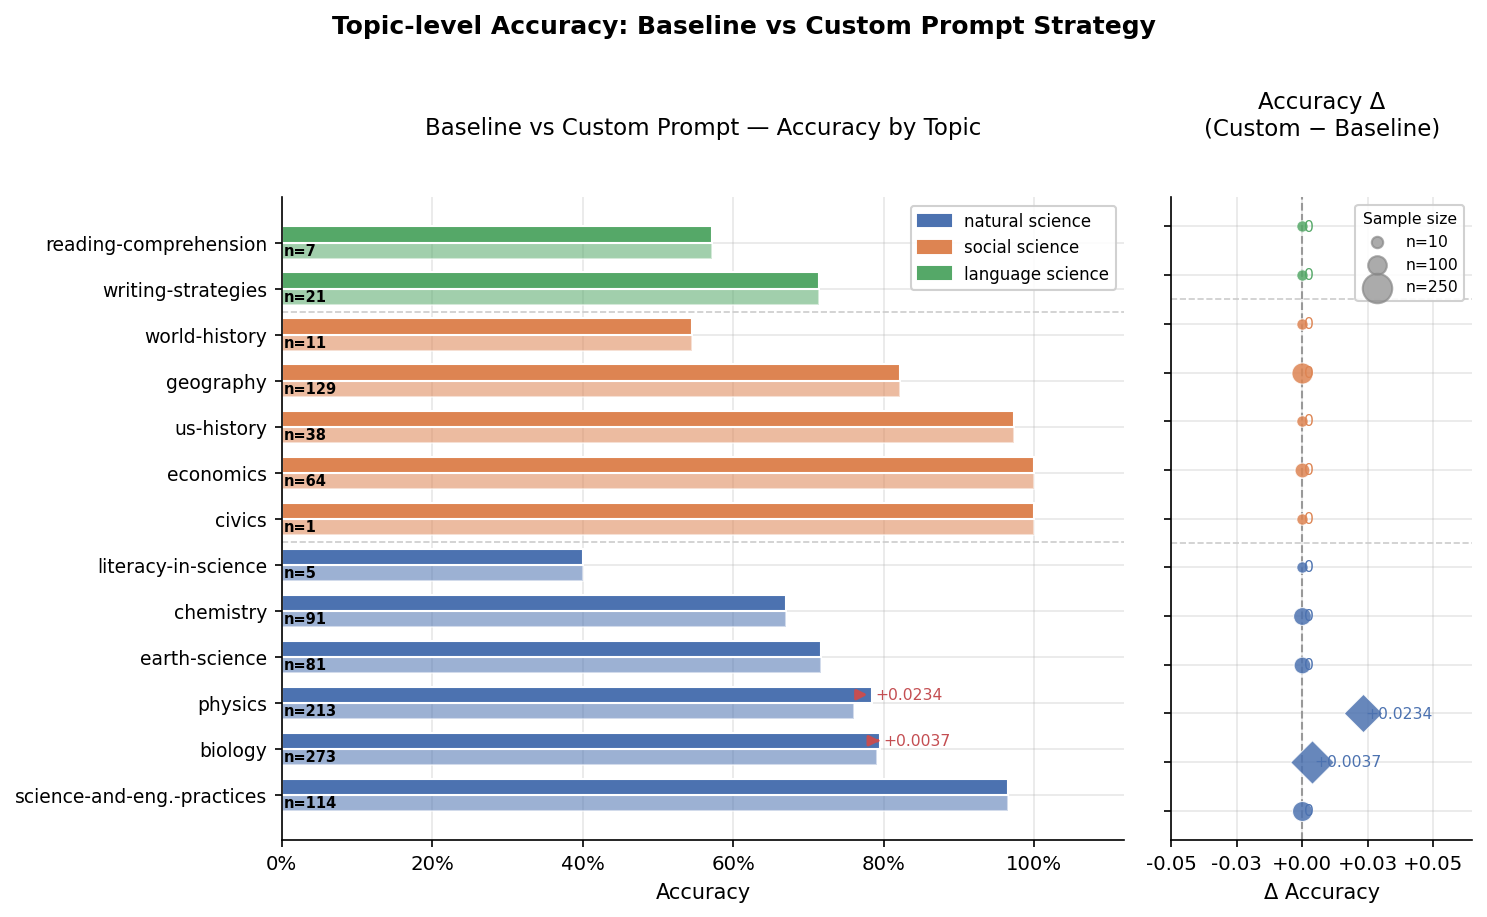

Saved → plot_topic_accuracy.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

matplotlib.rcParams.update({
    "figure.dpi":        150,
    "font.size":         9.5,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.axisbelow":    True,
})

# ── Data ──────────────────────────────────────────────────────────────────────
data = [
    ("natural science",  "biology",                          0.7912, 0.7949, 273),
    ("natural science",  "chemistry",                        0.6703, 0.6703,  91),
    ("social science",   "civics",                           1.0000, 1.0000,   1),
    ("natural science",  "earth-science",                    0.7160, 0.7160,  81),
    ("social science",   "economics",                        1.0000, 1.0000,  64),
    ("social science",   "geography",                        0.8217, 0.8217, 129),
    ("natural science",  "literacy-in-science",              0.4000, 0.4000,   5),
    ("natural science",  "physics",                          0.7606, 0.7840, 213),
    ("language science", "reading-comprehension",            0.5714, 0.5714,   7),
    ("natural science",  "science-and-eng.-practices",       0.9649, 0.9649, 114),
    ("social science",   "us-history",                       0.9737, 0.9737,  38),
    ("social science",   "world-history",                    0.5455, 0.5455,  11),
    ("language science", "writing-strategies",               0.7143, 0.7143,  21),
]

# Sort by subject then baseline descending
order = {"natural science": 0, "social science": 1, "language science": 2}
data.sort(key=lambda x: (order[x[0]], -x[2]))

subjects  = [d[0]  for d in data]
topics    = [d[1]  for d in data]
baselines = [d[2]  for d in data]
customs   = [d[3]  for d in data]
ns        = [d[4]  for d in data]
deltas    = [c - b for b, c in zip(baselines, customs)]

SUBJ_COLOR = {
    "natural science":  "#4C72B0",
    "social science":   "#DD8452",
    "language science": "#55A868",
}
bar_colors = [SUBJ_COLOR[s] for s in subjects]

n   = len(data)
y   = np.arange(n)
h   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(10, 6),
                         gridspec_kw={"width_ratios": [2.8, 1]})

# ── LEFT: grouped bar chart baseline vs custom ────────────────────────────────
ax = axes[0]
ax.barh(y - h/2, baselines, h, color=bar_colors, alpha=0.55,
        edgecolor="white", label="Baseline")
ax.barh(y + h/2, customs,   h, color=bar_colors, alpha=1.0,
        edgecolor="white", label="Custom")

# Improvement markers
for i, (b, c, d) in enumerate(zip(baselines, customs, deltas)):
    if d > 0:
        ax.annotate("", xy=(c, y[i] + h/2), xytext=(b, y[i] + h/2),
                    arrowprops=dict(arrowstyle="-|>", color="#C44E52",
                                   lw=1.5, mutation_scale=10))
        ax.text(c + 0.005, y[i] + h/2, f"+{d:.4f}",
                va="center", fontsize=7.5, color="#C44E52", fontweight="normal")
    # Annotate n
    ax.text(0.002, y[i] - h/2, f"n={ns[i]}",
            va="center", fontsize=7, color="black", fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(topics, fontsize=9)
ax.set_xlabel("Accuracy", fontsize=10)
ax.set_title("Baseline vs Custom Prompt — Accuracy by Topic", pad=30, fontweight="normal")
ax.set_xlim(0, 1.12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(True, axis="x", alpha=0.3)
ax.set_axisbelow(True)

# Subject colour legend
legend_patches = [mpatches.Patch(color=c, label=s)
                  for s, c in SUBJ_COLOR.items()]
bar_legend = [
    mpatches.Patch(color="#888", alpha=0.5, label="Baseline"),
    mpatches.Patch(color="#888", alpha=1.0, label="Custom"),
]
ax.legend(handles=legend_patches,
          fontsize=8, loc="upper right", framealpha=0.9)

# Subject group separators
boundaries = []
prev = subjects[0]
for i, s in enumerate(subjects):
    if s != prev:
        boundaries.append(i - 0.5)
        prev = s
for b in boundaries:
    ax.axhline(b, color="#ccc", linewidth=0.8, linestyle="--")

# ── RIGHT: delta dot plot (only topics with n >= 10) ─────────────────────────
ax2 = axes[1]
ax2.set_title("Accuracy Δ\n(Custom − Baseline)", pad=30, fontweight="normal")

for i, (d, s, t, ni) in enumerate(zip(deltas, subjects, topics, ns)):
    color  = SUBJ_COLOR[s]
    size   = max(30, ni * 0.8)   # bubble size proportional to n
    marker = "D" if d > 0 else ("o" if d == 0 else "v")
    ax2.scatter(d, i, s=size, color=color, alpha=0.85,
                marker=marker, edgecolors="white", linewidth=0.5, zorder=3)
    ax2.text(d + 0.0008, i, f"{d:+.4f}" if d != 0 else "0",
             va="center", fontsize=7.5, color=color)

ax2.axvline(0, color="#999", linewidth=1, linestyle="--")
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_xlabel("Δ Accuracy", fontsize=10)
ax2.set_xlim(-0.05, 0.065)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax2.grid(True, axis="x", alpha=0.3)
ax2.set_axisbelow(True)
for b in boundaries:
    ax2.axhline(b, color="#ccc", linewidth=0.8, linestyle="--")

# Bubble size legend
for ni_ex, label in [(10, "n=10"), (100, "n=100"), (250, "n=250")]:
    ax2.scatter([], [], s=max(30, ni_ex * 0.8), color="#888",
                alpha=0.7, label=label)
ax2.legend(fontsize=7.5, loc="upper right", title="Sample size",
           title_fontsize=7.5, framealpha=0.9)

fig.suptitle("Topic-level Accuracy: Baseline vs Custom Prompt Strategy",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_topic_accuracy.png",
            bbox_inches="tight")
plt.show()
print("Saved → plot_topic_accuracy.png")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78]
[0.9444, 0.7727, 0.5333]
['natural science', 'natural science', 'natural science']
['#4C72B0', '#4C72B0', '#4C72B0']


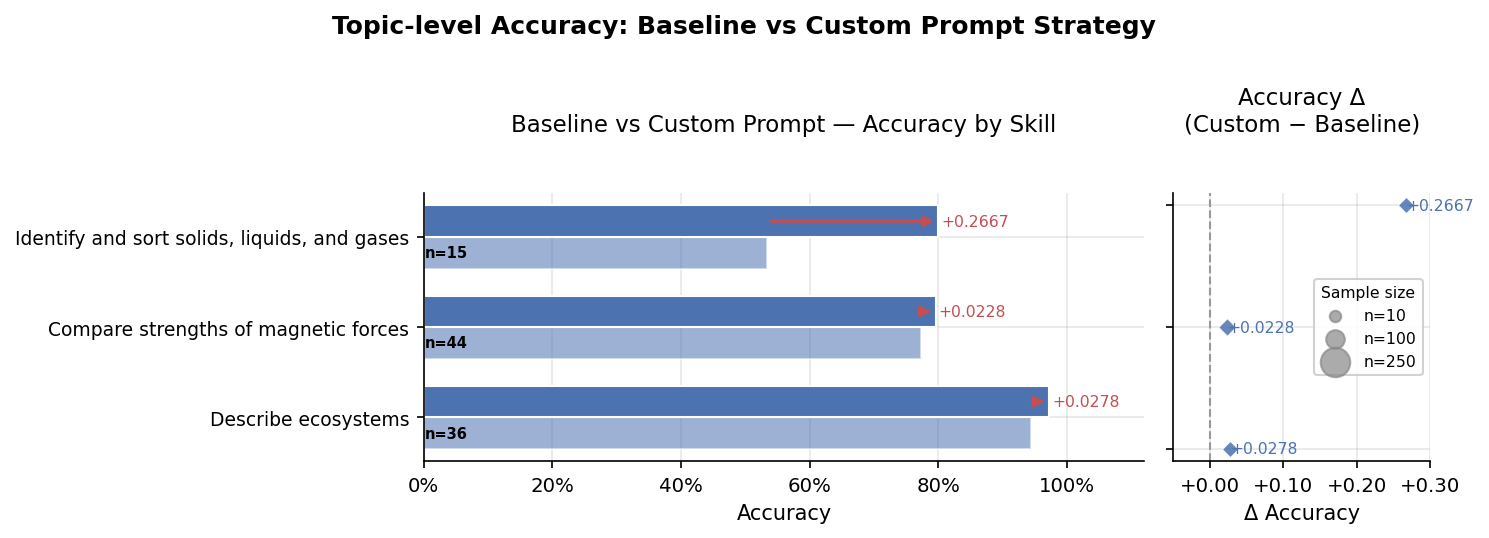

Saved → plot_skill_accuracy.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

matplotlib.rcParams.update({
    "figure.dpi":        150,
    "font.size":         9.5,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.axisbelow":    True,
})

# ── Data ──────────────────────────────────────────────────────────────────────
data = [
    ("natural science", "Analyze data to compare properties of planets", 0.6970, 0.6970, 33),
    ("social science", "Ancient Egyptian religion", 0.0000, 0.0000, 1),
    ("natural science", "Angiosperm and conifer life cycles", 1.0000, 1.0000, 2),
    ("natural science", "Animal adaptations: beaks, mouths, and necks", 1.0000, 1.0000, 19),
    ("natural science", "Animal adaptations: feet and limbs", 0.7500, 0.7500, 4),
    ("natural science", "Animal adaptations: skins and body coverings", 1.0000, 1.0000, 20),
    ("social science", "Antebellum Period: slavery and politics part I", 0.0000, 0.0000, 1),
    ("natural science", "Benefits of group behavior: African wild dogs", 0.0000, 0.0000, 1),
    ("social science", "Causes of the Civil War: Missouri Compromise to Bleeding Kansas", 1.0000, 1.0000, 2),
    ("language science", "Choose the sensory details that match the picture", 0.6667, 0.6667, 3),
    ("social science", "Cities of the Midwest", 0.5000, 0.5000, 2),
    ("social science", "Cities of the Northeast", 1.0000, 1.0000, 1),
    ("social science", "Cities of the Southeast", 0.0000, 0.0000, 1),
    ("social science", "Cities of the West", 1.0000, 1.0000, 1),
    ("natural science", "Classify fruits and vegetables as plant parts", 1.0000, 1.0000, 5),
    ("natural science", "Classify matter as solid, liquid, or gas", 1.0000, 1.0000, 13),
    ("natural science", "Classify rocks as igneous, sedimentary, or metamorphic", 0.5000, 0.5000, 2),
    ("natural science", "Classify symbiotic relationships", 0.7500, 0.7500, 4),
    ("natural science", "Compare ages of fossils in a rock sequence", 0.3750, 0.3750, 8),
    ("natural science", "Compare concentrations of solutions", 0.6034, 0.6034, 58),
    ("natural science", "Compare fossils to modern organisms", 0.7143, 0.7143, 7),
    ("natural science", "Compare magnitudes of magnetic forces", 0.7143, 0.7143, 70),
    ("natural science", "Compare strengths of magnetic forces", 0.7727, 0.7955, 44),
    ("natural science", "Describe and construct conifer life cycles", 1.0000, 1.0000, 3),
    ("natural science", "Describe ecosystems", 0.9444, 0.9722, 36),
    ("natural science", "Describe populations, communities, and ecosystems", 0.7500, 0.7500, 8),
    ("natural science", "Describe tectonic plate boundaries around the world", 1.0000, 1.0000, 4),
    ("natural science", "Describe the effects of gene mutations on organisms", 1.0000, 1.0000, 3),
    ("natural science", "Diffusion across membranes", 0.5556, 0.5556, 9),
    ("social science", "Early Roman society and politics", 0.0000, 0.0000, 1),
    ("natural science", "Evaluate claims about natural resource use: groundwater", 0.0000, 0.0000, 1),
    ("natural science", "Evaluate multiple design solutions to prevent flooding", 1.0000, 1.0000, 1),
    ("natural science", "Evaluate tests of engineering-design solutions", 1.0000, 1.0000, 52),
    ("natural science", "Explore chemical structure and properties: food flavors", 1.0000, 1.0000, 1),
    ("natural science", "Find evidence of changes to Earth's surface", 0.7500, 0.7500, 4),
    ("social science", "Foundations of Aztec civilization", 1.0000, 1.0000, 1),
    ("social science", "Foundations of Inca civilization", 0.0000, 0.0000, 1),
    ("social science", "French and English expeditions: part I", 0.0000, 0.0000, 1),
    ("natural science", "How can animal behaviors affect reproductive success? Identify evidence to support a claim", 0.0000, 0.0000, 2),
    ("natural science", "How do rock layers form?", 1.0000, 1.0000, 1),
    ("natural science", "Identify and compare air masses", 0.8000, 0.8000, 10),
    ("natural science", "Identify and sort solids, liquids, and gases", 0.5333, 0.8000, 15),
    ("language science", "Identify appeals to ethos, pathos, and logos in advertisements", 0.7222, 0.7222, 18),
    ("natural science", "Identify chemical formulas for ball-and-stick models", 1.0000, 1.0000, 2),
    ("natural science", "Identify control and experimental groups", 0.7778, 0.7778, 9),
    ("natural science", "Identify elementary substances and compounds using models", 0.9444, 0.9444, 18),
    ("natural science", "Identify how particle motion affects temperature and pressure", 0.8235, 0.8235, 68),
    ("natural science", "Identify independent and dependent variables", 0.3333, 0.3333, 3),
    ("natural science", "Identify mammals, birds, fish, reptiles, and amphibians", 0.8000, 0.8000, 20),
    ("natural science", "Identify pushes and pulls", 0.3333, 0.3333, 3),
    ("natural science", "Identify rocks and minerals", 1.0000, 1.0000, 1),
    ("natural science", "Identify roles in food chains", 0.8333, 0.8333, 6),
    ("social science", "Identify the Thirteen Colonies", 1.0000, 1.0000, 32),
    ("natural science", "Identify the experimental question", 1.0000, 1.0000, 50),
    ("natural science", "Interpret food webs", 1.0000, 1.0000, 5),
    ("natural science", "Interpret food webs I", 0.6667, 0.6667, 12),
    ("natural science", "Interpret food webs II", 0.3333, 0.3333, 15),
    ("social science", "Life as a colonist", 1.0000, 1.0000, 1),
    ("social science", "Major U.S. cities", 0.5000, 0.5000, 2),
    ("natural science", "Match chemical formulas to ball-and-stick models", 0.0000, 0.0000, 2),
    ("social science", "Mesopotamian empires", 1.0000, 1.0000, 2),
    ("social science", "Read a map: cardinal directions", 0.8913, 0.8913, 92),
    ("language science", "Read and understand informational passages", 1.0000, 1.0000, 1),
    ("language science", "Read passages about animals", 0.5000, 0.5000, 6),
    ("natural science", "Seed disperser: common ostrich", 1.0000, 1.0000, 1),
    ("social science", "State and local government", 1.0000, 1.0000, 1),
    ("social science", "The American Revolution: struggle for independence", 1.0000, 1.0000, 1),
    ("social science", "The Mongol Empire", 0.5000, 0.5000, 2),
    ("social science", "The abolitionists", 1.0000, 1.0000, 1),
    ("social science", "The ancient Silk Road: geography and transportation", 1.0000, 1.0000, 1),
    ("social science", "The fall of the Western Roman Empire", 1.0000, 1.0000, 1),
    ("social science", "Trade and specialization", 1.0000, 1.0000, 64),
    ("natural science", "Use Punnett squares to calculate probabilities of offspring types", 0.2727, 0.2727, 22),
    ("natural science", "Use Punnett squares to calculate ratios of offspring types", 0.2381, 0.2381, 21),
    ("social science", "Use a letter-number grid", 0.1667, 0.1667, 12),
    ("natural science", "Use climate data to make predictions", 0.9000, 0.9000, 10),
    ("social science", "Use lines of latitude and longitude", 1.0000, 1.0000, 18),
    ("natural science", "Use scientific names to classify organisms", 1.0000, 1.0000, 68),
    ("natural science", "What are atoms and chemical elements?", 1.0000, 1.0000, 1),
]

# Sort by subject then baseline descending
order = {"natural science": 0, "social science": 1, "language science": 2}
data.sort(key=lambda x: (order[x[0]], -x[2]))

subjects  = [d[0]  for d in data]
topics    = [d[1]  for d in data]
baselines = [d[2]  for d in data]
customs   = [d[3]  for d in data]
ns        = [d[4]  for d in data]
deltas    = [c - b for b, c in zip(baselines, customs)]

rm_idxs = []
for i in range(len(data)):
    if deltas[i] == 0:
        rm_idxs.append(i)

for i in reversed(rm_idxs):
        subjects.pop(i)
        topics.pop(i)
        baselines.pop(i)
        customs.pop(i)
        ns.pop(i)
        deltas.pop(i)

print(rm_idxs)
print(baselines)
print(subjects)

SUBJ_COLOR = {
    "natural science":  "#4C72B0",
    "social science":   "#DD8452",
    "language science": "#55A868",
}
bar_colors = [SUBJ_COLOR[s] for s in subjects]

print(bar_colors)

n   = len(deltas)
y   = np.arange(n)
h   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5),
                         gridspec_kw={"width_ratios": [2.8, 1]})

# ── LEFT: grouped bar chart baseline vs custom ────────────────────────────────
ax = axes[0]
ax.barh(y - h/2, baselines, h, color=bar_colors, alpha=0.55,
        edgecolor="white", label="Baseline")
ax.barh(y + h/2, customs,   h, color=bar_colors, alpha=1.0,
        edgecolor="white", label="Custom")

# Improvement markers
for i, (b, c, d) in enumerate(zip(baselines, customs, deltas)):
    if d > 0:
        ax.annotate("", xy=(c, y[i] + h/2), xytext=(b, y[i] + h/2),
                    arrowprops=dict(arrowstyle="-|>", color="#C44E52",
                                   lw=1.5, mutation_scale=10))
        ax.text(c + 0.005, y[i] + h/2, f"+{d:.4f}",
                va="center", fontsize=7.5, color="#C44E52", fontweight="normal")
    # Annotate n
    ax.text(0.002, y[i] - h/2, f"n={ns[i]}",
            va="center", fontsize=7, color="black", fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(topics, fontsize=9)
ax.set_xlabel("Accuracy", fontsize=10)
ax.set_title("Baseline vs Custom Prompt — Accuracy by Skill", pad=30, fontweight="normal")
ax.set_xlim(0, 1.12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(True, axis="x", alpha=0.3)
ax.set_axisbelow(True)

# Subject colour legend
legend_patches = [mpatches.Patch(color=c, label=s)
                  for s, c in SUBJ_COLOR.items()]
bar_legend = [
    mpatches.Patch(color="#888", alpha=0.5, label="Baseline"),
    mpatches.Patch(color="#888", alpha=1.0, label="Custom"),
]
ax.legend(handles=legend_patches + bar_legend,
          fontsize=8, loc="upper right", framealpha=0.9)
ax.get_legend().remove()

# Subject group separators
boundaries = []
prev = subjects[0]
for i, s in enumerate(subjects):
    if s != prev:
        boundaries.append(i - 0.5)
        prev = s
for b in boundaries:
    ax.axhline(b, color="#ccc", linewidth=0.8, linestyle="--")

# ── RIGHT: delta dot plot (only topics with n >= 10) ─────────────────────────
ax2 = axes[1]
ax2.set_title("Accuracy Δ\n(Custom − Baseline)", pad=30, fontweight="normal")

for i, (d, s, t, ni) in enumerate(zip(deltas, subjects, topics, ns)):
    color  = SUBJ_COLOR[s]
    size   = max(30, ni * 0.8)   # bubble size proportional to n
    marker = "D" if d > 0 else ("o" if d == 0 else "v")
    ax2.scatter(d, i, s=size, color=color, alpha=0.85,
                marker=marker, edgecolors="white", linewidth=0.5, zorder=3)
    ax2.text(d + 0.0008, i, f"{d:+.4f}" if d != 0 else "0",
             va="center", fontsize=7.5, color=color)

ax2.axvline(0, color="#999", linewidth=1, linestyle="--")
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_xlabel("Δ Accuracy", fontsize=10)
ax2.set_xlim(-0.05, 0.3)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax2.grid(True, axis="x", alpha=0.3)
ax2.set_axisbelow(True)
for b in boundaries:
    ax2.axhline(b, color="#ccc", linewidth=0.8, linestyle="--")

# Bubble size legend
for ni_ex, label in [(10, "n=10"), (100, "n=100"), (250, "n=250")]:
    ax2.scatter([], [], s=max(30, ni_ex * 0.8), color="#888",
                alpha=0.7, label=label)
ax2.legend(fontsize=7.5, loc="center right", title="Sample size",
           title_fontsize=7.5, framealpha=0.9)

fig.suptitle("Topic-level Accuracy: Baseline vs Custom Prompt Strategy",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_skill_accuracy.png",
            bbox_inches="tight")
plt.show()
print("Saved → plot_skill_accuracy.png")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 75, 76, 77]
[0.9444, 0.7727, 0.5556, 0.5333, 0.5, 0.375, 0.3333, 0.3333, 0.3333, 0.2727, 0.2381, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.5, 0.1667, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5]
['natural science', 'natural science', 'natural science', 'natural science', 'natural science', 'natural science', 'natural science', 'natural science', 'natural science', 'natural science', 'natural science', 'natural science', 'natural science', 'natural science', 'natural science', 'social science', 'social science', 'social science', 'social science', 'social science', 'social science', 'social science', 'social science', 'social science', 'social science', 'language science']
['#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C

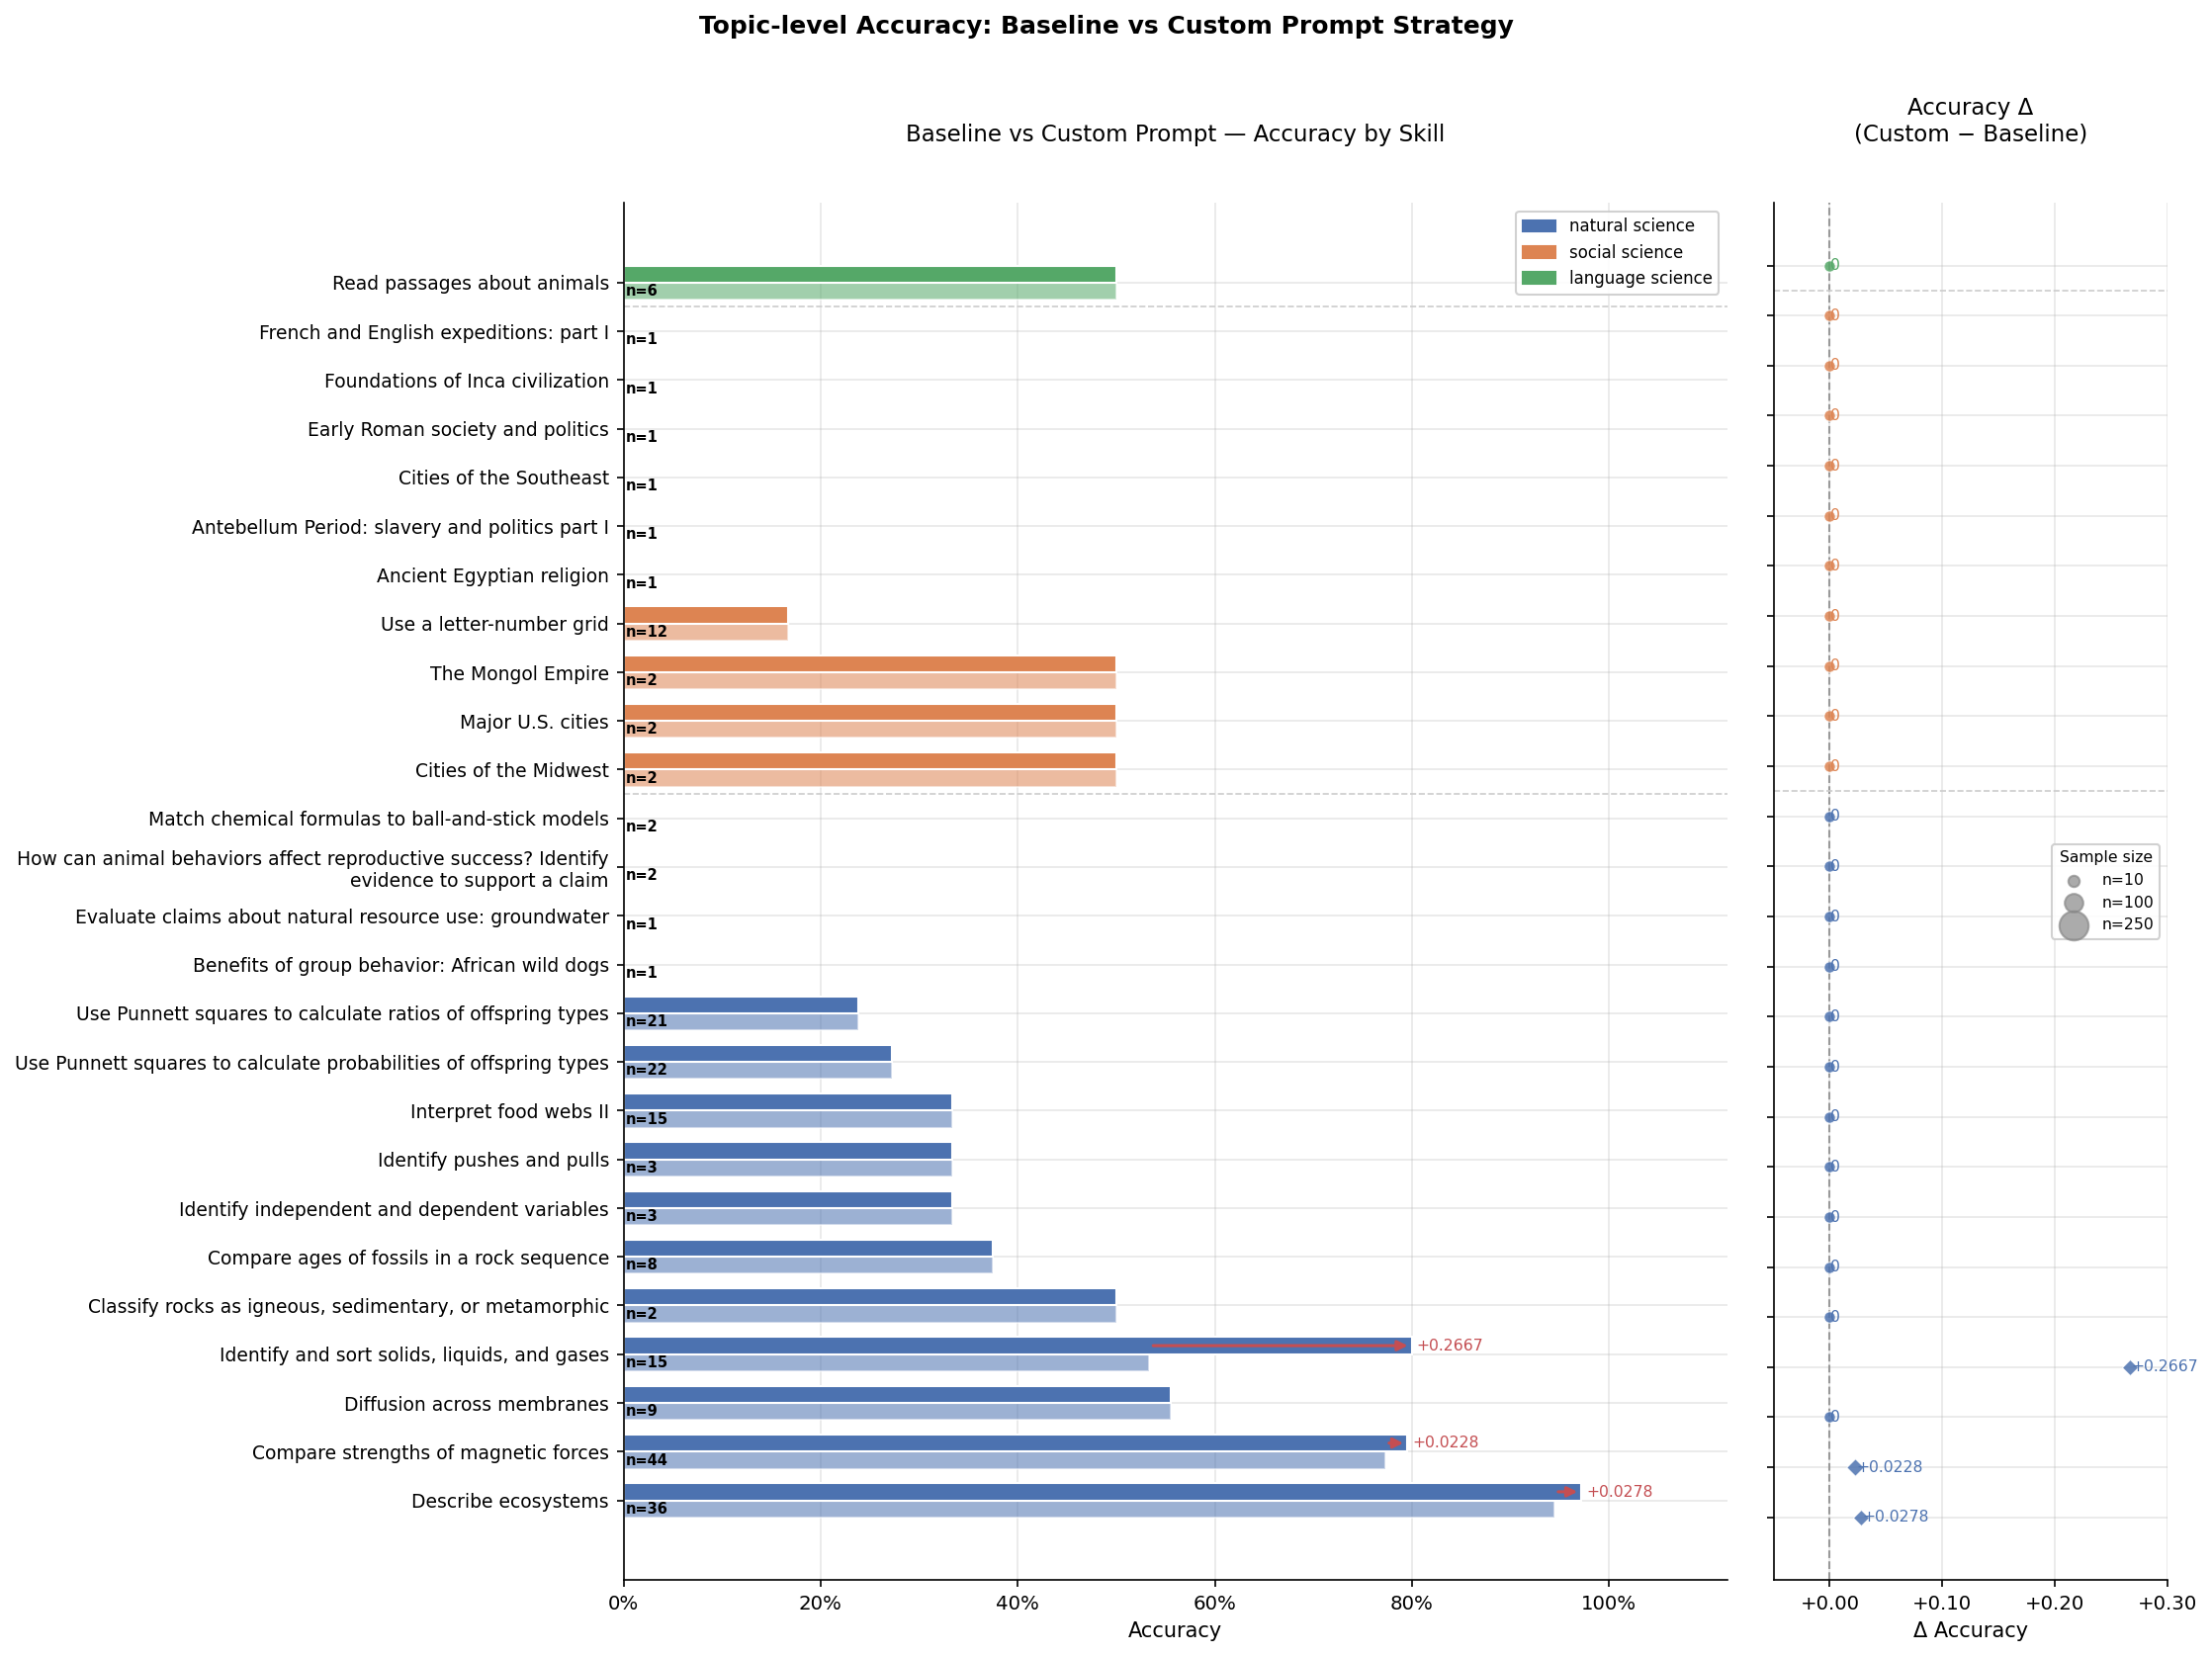

Saved → plot_skill_accuracy_full.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import textwrap

matplotlib.rcParams.update({
    "figure.dpi":        150,
    "font.size":         9.5,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.axisbelow":    True,
})

# ── Data ──────────────────────────────────────────────────────────────────────
data = [
    ("natural science", "Analyze data to compare properties of planets", 0.6970, 0.6970, 33),
    ("social science", "Ancient Egyptian religion", 0.0000, 0.0000, 1),
    ("natural science", "Angiosperm and conifer life cycles", 1.0000, 1.0000, 2),
    ("natural science", "Animal adaptations: beaks, mouths, and necks", 1.0000, 1.0000, 19),
    ("natural science", "Animal adaptations: feet and limbs", 0.7500, 0.7500, 4),
    ("natural science", "Animal adaptations: skins and body coverings", 1.0000, 1.0000, 20),
    ("social science", "Antebellum Period: slavery and politics part I", 0.0000, 0.0000, 1),
    ("natural science", "Benefits of group behavior: African wild dogs", 0.0000, 0.0000, 1),
    ("social science", "Causes of the Civil War: Missouri Compromise to Bleeding Kansas", 1.0000, 1.0000, 2),
    ("language science", "Choose the sensory details that match the picture", 0.6667, 0.6667, 3),
    ("social science", "Cities of the Midwest", 0.5000, 0.5000, 2),
    ("social science", "Cities of the Northeast", 1.0000, 1.0000, 1),
    ("social science", "Cities of the Southeast", 0.0000, 0.0000, 1),
    ("social science", "Cities of the West", 1.0000, 1.0000, 1),
    ("natural science", "Classify fruits and vegetables as plant parts", 1.0000, 1.0000, 5),
    ("natural science", "Classify matter as solid, liquid, or gas", 1.0000, 1.0000, 13),
    ("natural science", "Classify rocks as igneous, sedimentary, or metamorphic", 0.5000, 0.5000, 2),
    ("natural science", "Classify symbiotic relationships", 0.7500, 0.7500, 4),
    ("natural science", "Compare ages of fossils in a rock sequence", 0.3750, 0.3750, 8),
    ("natural science", "Compare concentrations of solutions", 0.6034, 0.6034, 58),
    ("natural science", "Compare fossils to modern organisms", 0.7143, 0.7143, 7),
    ("natural science", "Compare magnitudes of magnetic forces", 0.7143, 0.7143, 70),
    ("natural science", "Compare strengths of magnetic forces", 0.7727, 0.7955, 44),
    ("natural science", "Describe and construct conifer life cycles", 1.0000, 1.0000, 3),
    ("natural science", "Describe ecosystems", 0.9444, 0.9722, 36),
    ("natural science", "Describe populations, communities, and ecosystems", 0.7500, 0.7500, 8),
    ("natural science", "Describe tectonic plate boundaries around the world", 1.0000, 1.0000, 4),
    ("natural science", "Describe the effects of gene mutations on organisms", 1.0000, 1.0000, 3),
    ("natural science", "Diffusion across membranes", 0.5556, 0.5556, 9),
    ("social science", "Early Roman society and politics", 0.0000, 0.0000, 1),
    ("natural science", "Evaluate claims about natural resource use: groundwater", 0.0000, 0.0000, 1),
    ("natural science", "Evaluate multiple design solutions to prevent flooding", 1.0000, 1.0000, 1),
    ("natural science", "Evaluate tests of engineering-design solutions", 1.0000, 1.0000, 52),
    ("natural science", "Explore chemical structure and properties: food flavors", 1.0000, 1.0000, 1),
    ("natural science", "Find evidence of changes to Earth's surface", 0.7500, 0.7500, 4),
    ("social science", "Foundations of Aztec civilization", 1.0000, 1.0000, 1),
    ("social science", "Foundations of Inca civilization", 0.0000, 0.0000, 1),
    ("social science", "French and English expeditions: part I", 0.0000, 0.0000, 1),
    ("natural science", "How can animal behaviors affect reproductive success? Identify evidence to support a claim", 0.0000, 0.0000, 2),
    ("natural science", "How do rock layers form?", 1.0000, 1.0000, 1),
    ("natural science", "Identify and compare air masses", 0.8000, 0.8000, 10),
    ("natural science", "Identify and sort solids, liquids, and gases", 0.5333, 0.8000, 15),
    ("language science", "Identify appeals to ethos, pathos, and logos in advertisements", 0.7222, 0.7222, 18),
    ("natural science", "Identify chemical formulas for ball-and-stick models", 1.0000, 1.0000, 2),
    ("natural science", "Identify control and experimental groups", 0.7778, 0.7778, 9),
    ("natural science", "Identify elementary substances and compounds using models", 0.9444, 0.9444, 18),
    ("natural science", "Identify how particle motion affects temperature and pressure", 0.8235, 0.8235, 68),
    ("natural science", "Identify independent and dependent variables", 0.3333, 0.3333, 3),
    ("natural science", "Identify mammals, birds, fish, reptiles, and amphibians", 0.8000, 0.8000, 20),
    ("natural science", "Identify pushes and pulls", 0.3333, 0.3333, 3),
    ("natural science", "Identify rocks and minerals", 1.0000, 1.0000, 1),
    ("natural science", "Identify roles in food chains", 0.8333, 0.8333, 6),
    ("social science", "Identify the Thirteen Colonies", 1.0000, 1.0000, 32),
    ("natural science", "Identify the experimental question", 1.0000, 1.0000, 50),
    ("natural science", "Interpret food webs", 1.0000, 1.0000, 5),
    ("natural science", "Interpret food webs I", 0.6667, 0.6667, 12),
    ("natural science", "Interpret food webs II", 0.3333, 0.3333, 15),
    ("social science", "Life as a colonist", 1.0000, 1.0000, 1),
    ("social science", "Major U.S. cities", 0.5000, 0.5000, 2),
    ("natural science", "Match chemical formulas to ball-and-stick models", 0.0000, 0.0000, 2),
    ("social science", "Mesopotamian empires", 1.0000, 1.0000, 2),
    ("social science", "Read a map: cardinal directions", 0.8913, 0.8913, 92),
    ("language science", "Read and understand informational passages", 1.0000, 1.0000, 1),
    ("language science", "Read passages about animals", 0.5000, 0.5000, 6),
    ("natural science", "Seed disperser: common ostrich", 1.0000, 1.0000, 1),
    ("social science", "State and local government", 1.0000, 1.0000, 1),
    ("social science", "The American Revolution: struggle for independence", 1.0000, 1.0000, 1),
    ("social science", "The Mongol Empire", 0.5000, 0.5000, 2),
    ("social science", "The abolitionists", 1.0000, 1.0000, 1),
    ("social science", "The ancient Silk Road: geography and transportation", 1.0000, 1.0000, 1),
    ("social science", "The fall of the Western Roman Empire", 1.0000, 1.0000, 1),
    ("social science", "Trade and specialization", 1.0000, 1.0000, 64),
    ("natural science", "Use Punnett squares to calculate probabilities of offspring types", 0.2727, 0.2727, 22),
    ("natural science", "Use Punnett squares to calculate ratios of offspring types", 0.2381, 0.2381, 21),
    ("social science", "Use a letter-number grid", 0.1667, 0.1667, 12),
    ("natural science", "Use climate data to make predictions", 0.9000, 0.9000, 10),
    ("social science", "Use lines of latitude and longitude", 1.0000, 1.0000, 18),
    ("natural science", "Use scientific names to classify organisms", 1.0000, 1.0000, 68),
    ("natural science", "What are atoms and chemical elements?", 1.0000, 1.0000, 1),
]

# Sort by subject then baseline descending
order = {"natural science": 0, "social science": 1, "language science": 2}
data.sort(key=lambda x: (order[x[0]], -x[2]))

subjects  = [d[0]  for d in data]
topics    = [d[1]  for d in data]
baselines = [d[2]  for d in data]
customs   = [d[3]  for d in data]
ns        = [d[4]  for d in data]
deltas    = [c - b for b, c in zip(baselines, customs)]

# Wrap labels at a specific character width (e.g., 10 characters)
topics = [textwrap.fill(label, width=65) for label in topics]

rm_idxs = []
for i in range(len(data)):
    if baselines[i] > 0.6 and deltas[i] == 0:
        rm_idxs.append(i)

for i in reversed(rm_idxs):
        subjects.pop(i)
        topics.pop(i)
        baselines.pop(i)
        customs.pop(i)
        ns.pop(i)
        deltas.pop(i)

print(rm_idxs)
print(baselines)
print(subjects)

SUBJ_COLOR = {
    "natural science":  "#4C72B0",
    "social science":   "#DD8452",
    "language science": "#55A868",
}
bar_colors = [SUBJ_COLOR[s] for s in subjects]

print(bar_colors)

n   = len(deltas)
y   = np.arange(n)
h   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 11),
                         gridspec_kw={"width_ratios": [2.8, 1]})

# ── LEFT: grouped bar chart baseline vs custom ────────────────────────────────
ax = axes[0]
ax.barh(y - h/2, baselines, h, color=bar_colors, alpha=0.55,
        edgecolor="white", label="Baseline")
ax.barh(y + h/2, customs,   h, color=bar_colors, alpha=1.0,
        edgecolor="white", label="Custom")

# Improvement markers
for i, (b, c, d) in enumerate(zip(baselines, customs, deltas)):
    if d > 0:
        ax.annotate("", xy=(c, y[i] + h/2), xytext=(b, y[i] + h/2),
                    arrowprops=dict(arrowstyle="-|>", color="#C44E52",
                                   lw=1.5, mutation_scale=10))
        ax.text(c + 0.005, y[i] + h/2, f"+{d:.4f}",
                va="center", fontsize=7.5, color="#C44E52", fontweight="normal")
    # Annotate n
    ax.text(0.002, y[i] - h/2, f"n={ns[i]}",
            va="center", fontsize=7, color="black", fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(topics, fontsize=9)
ax.set_xlabel("Accuracy", fontsize=10)
ax.set_title("Baseline vs Custom Prompt — Accuracy by Skill", pad=30, fontweight="normal")
ax.set_xlim(0, 1.12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(True, axis="x", alpha=0.3)
ax.set_axisbelow(True)

# Subject colour legend
legend_patches = [mpatches.Patch(color=c, label=s)
                  for s, c in SUBJ_COLOR.items()]
bar_legend = [
    mpatches.Patch(color="#888", alpha=0.5, label="Baseline"),
    mpatches.Patch(color="#888", alpha=1.0, label="Custom"),
]
ax.legend(handles=legend_patches,
          fontsize=8, loc="upper right", framealpha=0.9)
# ax.get_legend().remove()

# Subject group separators
boundaries = []
prev = subjects[0]
for i, s in enumerate(subjects):
    if s != prev:
        boundaries.append(i - 0.5)
        prev = s
for b in boundaries:
    ax.axhline(b, color="#ccc", linewidth=0.8, linestyle="--")

# ── RIGHT: delta dot plot (only topics with n >= 10) ─────────────────────────
ax2 = axes[1]
ax2.set_title("Accuracy Δ\n(Custom − Baseline)", pad=30, fontweight="normal")

for i, (d, s, t, ni) in enumerate(zip(deltas, subjects, topics, ns)):
    color  = SUBJ_COLOR[s]
    size   = max(30, ni * 0.8)   # bubble size proportional to n
    marker = "D" if d > 0 else ("o" if d == 0 else "v")
    ax2.scatter(d, i, s=size, color=color, alpha=0.85,
                marker=marker, edgecolors="white", linewidth=0.5, zorder=3)
    ax2.text(d + 0.0008, i, f"{d:+.4f}" if d != 0 else "0",
             va="center", fontsize=7.5, color=color)

ax2.axvline(0, color="#999", linewidth=1, linestyle="--")
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_xlabel("Δ Accuracy", fontsize=10)
ax2.set_xlim(-0.05, 0.3)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax2.grid(True, axis="x", alpha=0.3)
ax2.set_axisbelow(True)
for b in boundaries:
    ax2.axhline(b, color="#ccc", linewidth=0.8, linestyle="--")

# Bubble size legend
for ni_ex, label in [(10, "n=10"), (100, "n=100"), (250, "n=250")]:
    ax2.scatter([], [], s=max(30, ni_ex * 0.8), color="#888",
                alpha=0.7, label=label)
ax2.legend(fontsize=7.5, loc="center right", title="Sample size",
           title_fontsize=7.5, framealpha=0.9)

fig.suptitle("Topic-level Accuracy: Baseline vs Custom Prompt Strategy",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_skill_accuracy_full.png",
            bbox_inches="tight")
plt.show()
print("Saved → plot_skill_accuracy_full.png")

# 11. Plot Ablation Studies

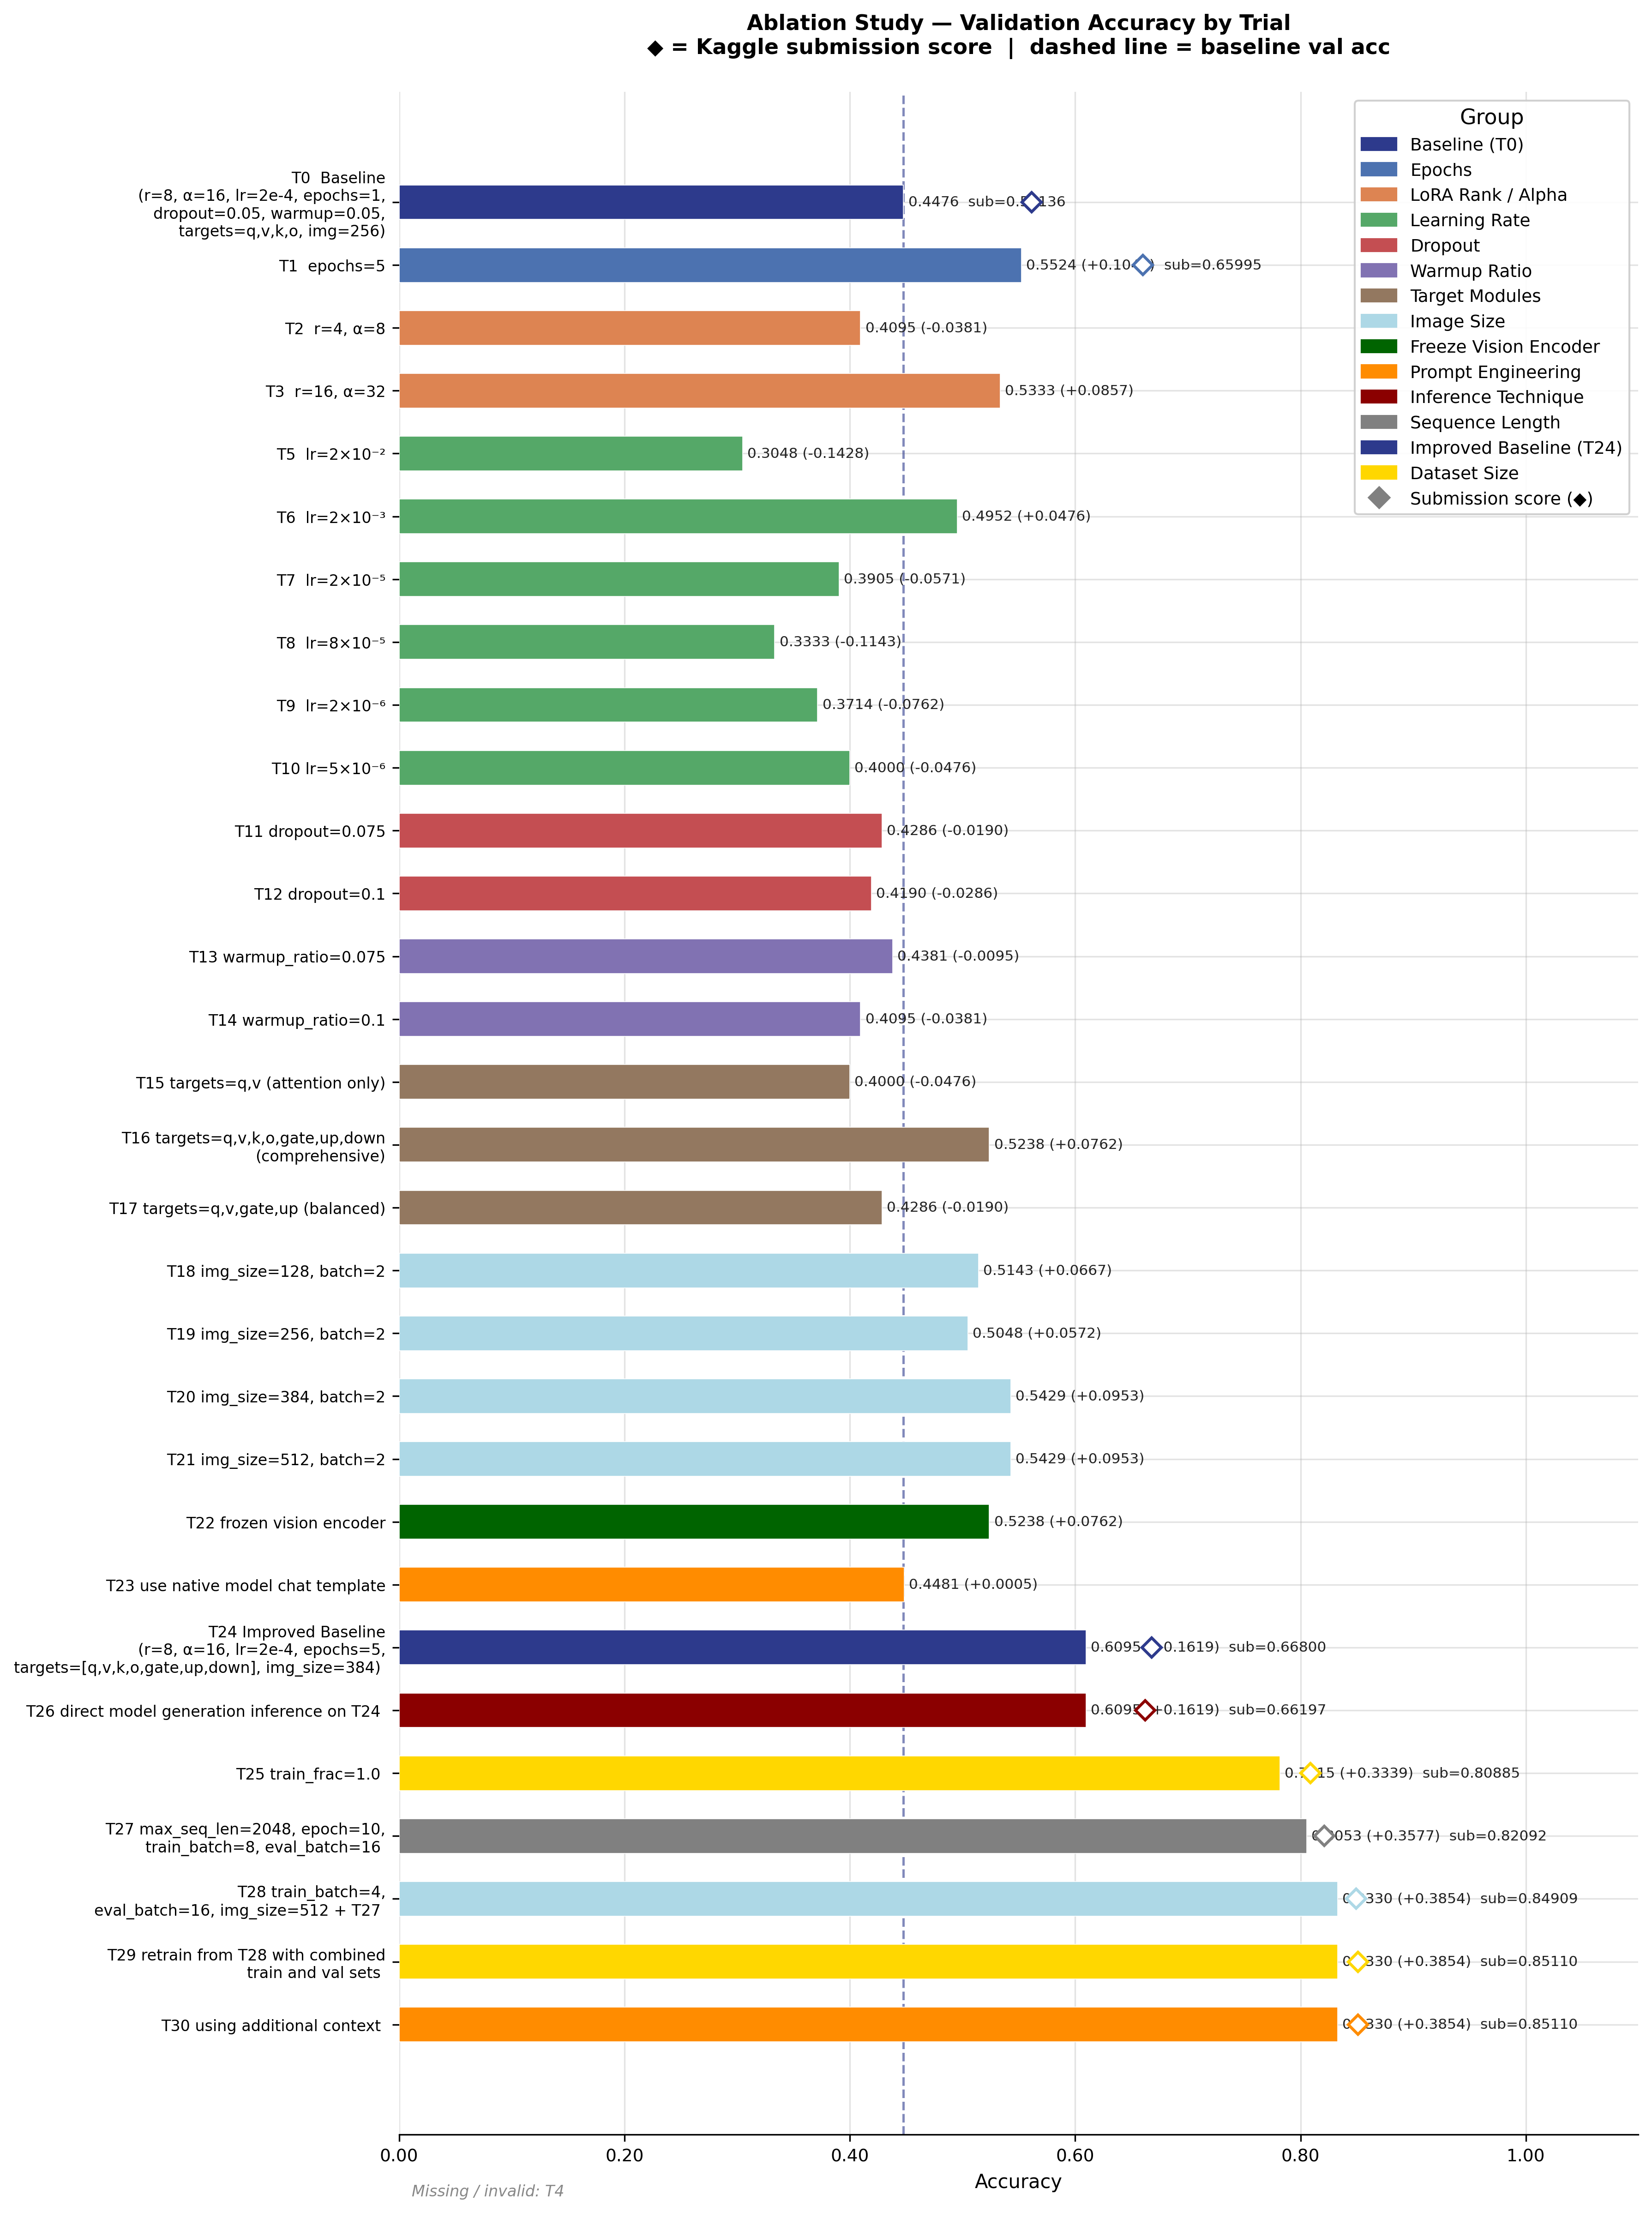

Saved → ablation_val_accuracy.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

matplotlib.rcParams.update({
    "figure.dpi":        300,
    "font.size":         9,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "axes.axisbelow":    True,
})

# ── Data parsed from the LaTeX table ─────────────────────────────────────────
# (trial, label, val_acc, sub_score, group)
# val_acc = None where data was missing (trial 4)
# sub_score = None where not submitted
DATA = [
    # trial  label                                     val_acc   sub     group
    (0,  "T0  Baseline\n(r=8, α=16, lr=2e-4, epochs=1,\ndropout=0.05, warmup=0.05,\ntargets=q,v,k,o, img=256)",
                                                       0.4476,  0.56136, "baseline"),
    (1,  "T1  epochs=5",                               0.5524,  0.65995, "epochs"),
    (2,  "T2  r=4, α=8",                               0.4095,  None,    "lora_rank"),
    (3,  "T3  r=16, α=32",                             0.5333,  None,    "lora_rank"),
    (4,  "T4  r=32, α=64  (>5M params)",               None,    None,    "lora_rank"),
    (5,  "T5  lr=2×10⁻²",                              0.3048,  None,    "lr"),
    (6,  "T6  lr=2×10⁻³",                              0.4952,  None,    "lr"),
    (7,  "T7  lr=2×10⁻⁵",                              0.3905,  None,    "lr"),
    (8,  "T8  lr=8×10⁻⁵",                              0.3333,  None,    "lr"),
    (9,  "T9  lr=2×10⁻⁶",                              0.3714,  None,    "lr"),
    (10, "T10 lr=5×10⁻⁶",                              0.4000,  None,    "lr"),
    (11, "T11 dropout=0.075",                           0.4286,  None,    "dropout"),
    (12, "T12 dropout=0.1",                             0.4190,  None,    "dropout"),
    (13, "T13 warmup_ratio=0.075",                      0.4381,  None,    "warmup"),
    (14, "T14 warmup_ratio=0.1",                        0.4095,  None,    "warmup"),
    (15, "T15 targets=q,v (attention only)",            0.4000,  None,    "targets"),
    (16, "T16 targets=q,v,k,o,gate,up,down\n(comprehensive)",
                                                       0.5238,  None,    "targets"),
    (17, "T17 targets=q,v,gate,up (balanced)",          0.4286,  None,    "targets"),
    (18, "T18 img_size=128, batch=2",                   0.5143,  None,    "img_size"),
    (19, "T19 img_size=256, batch=2",                   0.5048,  None,    "img_size"),
    (20, "T20 img_size=384, batch=2",                   0.5429,  None,    "img_size"),
    (21, "T21 img_size=512, batch=2",                   0.5429,  None,    "img_size"),
    (22, "T22 frozen vision encoder",                   0.5238,  None,    "vision"),
    (23, "T23 use native model chat template",                   0.4481,  None,    "prompt"),
    (24, "T24 Improved Baseline\n(r=8, α=16, lr=2e-4, epochs=5,\ntargets=[q,v,k,o,gate,up,down], img_size=384) ", 0.6095,  0.6680,    "improved_baseline"),
    (25, "T26 direct model generation inference on T24 ",                   0.6095,  0.66197,    "inference"),
    (26, "T25 train_frac=1.0 ",                   0.7815,  0.80885,    "dataset"),
    (27, "T27 max_seq_len=2048, epoch=10,\ntrain_batch=8, eval_batch=16 ",                   0.805343,  0.82092,    "seq length"),
    (28, "T28 train_batch=4,\neval_batch=16, img_size=512 + T27 ",                   0.8330,  0.84909,    "img_size"),
    (29, "T29 retrain from T28 with combined\ntrain and val sets ",                   0.8330,  0.8511,    "dataset"),
    (30, "T30 using additional context ",                   0.8330,  0.8511,    "prompt"),
]

#

# ── Colour palette by group ───────────────────────────────────────────────────
GROUP_COLORS = {
    "baseline":  "#2D3A8C",
    "epochs":    "#4C72B0",
    "lora_rank": "#DD8452",
    "lr":        "#55A868",
    "dropout":   "#C44E52",
    "warmup":    "#8172B2",
    "targets":   "#937860",
    "img_size":  "lightblue",
    "vision": "darkgreen",
    "prompt": "darkorange",
    "inference": "darkred",
    "seq length" : "grey",
    "improved_baseline" : "#2D3A8C",
    "dataset" : "gold",
}
GROUP_LABELS = {
    "baseline":  "Baseline (T0)",
    "epochs":    "Epochs",
    "lora_rank": "LoRA Rank / Alpha",
    "lr":        "Learning Rate",
    "dropout":   "Dropout",
    "warmup":    "Warmup Ratio",
    "targets":   "Target Modules",
    "img_size":  "Image Size",
    "vision": "Freeze Vision Encoder",
    "prompt": "Prompt Engineering",
    "inference": "Inference Technique",
    "seq length" : "Sequence Length",
    "improved_baseline" : "Improved Baseline (T24)",
    "dataset" : "Dataset Size",
}

# ── Separate valid and missing entries ────────────────────────────────────────
valid   = [(t, lbl, va, sub, grp) for t, lbl, va, sub, grp in DATA if va is not None]
missing = [(t, lbl, va, sub, grp) for t, lbl, va, sub, grp in DATA if va is None]

labels    = [d[1] for d in valid]
val_accs  = [d[2] for d in valid]
sub_scores= [d[3] for d in valid]
groups    = [d[4] for d in valid]
bar_colors= [GROUP_COLORS[g] for g in groups]

n = len(valid)
y = np.arange(n)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 16))

# Validation accuracy bars
bars = ax.barh(y, val_accs, height=0.55,
               color=bar_colors, edgecolor="white", linewidth=0.4,
               label="Val Accuracy", zorder=3)

# Submission score markers (diamond) where available
for i, (_, _, va, sub, _) in enumerate(valid):
    if sub is not None:
        ax.plot(sub, i, marker="D", color="white",
                markeredgecolor=bar_colors[i], markeredgewidth=1.5,
                markersize=7, zorder=5, clip_on=False)

# Baseline reference line
baseline_acc = valid[0][2]
ax.axvline(baseline_acc, color="#2D3A8C", linestyle="--",
           linewidth=1.2, alpha=0.6, zorder=2,
           label=f"Baseline val acc ({baseline_acc:.4f})")

# Value annotations on each bar
x_max = max(val_accs) if val_accs else 1
for i, (bar, va, sub) in enumerate(zip(bars, val_accs, sub_scores)):
    delta = va - baseline_acc
    delta_str = f" ({delta:+.4f})" if i > 0 else ""
    sub_str   = f"  sub={sub:.5f}" if sub is not None else ""
    ax.text(va + x_max * 0.005, i,
            f"{va:.4f}{delta_str}{sub_str}",
            va="center", ha="left", fontsize=7.5, color="#222")

# Missing trials note
if missing:
    missing_str = ", ".join(f"T{t}" for t, *_ in missing)
    ax.text(0.01, -0.03, f"Missing / invalid: {missing_str}",
            transform=ax.transAxes, fontsize=8, color="#888", style="italic")

# Axes formatting
ax.set_yticks(y)
ax.grid(True, axis="x", alpha=0.35)
ax.set_axisbelow(True)
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()                          # T0 at top
ax.set_xlabel("Accuracy", fontsize=10)
ax.set_xlim(0, x_max * 1.32)
ax.xaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:.2f}")
)
ax.set_title(
    "Ablation Study — Validation Accuracy by Trial\n"
    "◆ = Kaggle submission score  |  dashed line = baseline val acc",
    fontsize=11, fontweight="bold", pad=20,
)

# Group legend
legend_patches = [
    mpatches.Patch(color=GROUP_COLORS[g], label=GROUP_LABELS[g])
    for g in GROUP_COLORS
]
sub_marker = plt.Line2D([], [], marker="D", color="grey",
                        markeredgecolor="grey", markeredgewidth=1.5,
                        markersize=7, linestyle="none",
                        label="Submission score (◆)")
ax.legend(
    handles=legend_patches + [sub_marker],
    loc="upper right", fontsize=9,
    framealpha=0.9, edgecolor="#ccc",
    title="Group", title_fontsize=11,
)

plt.tight_layout()
plt.savefig(OUT_DIR / "ablation_val_accuracy.png", bbox_inches="tight")
plt.show()
print("Saved → ablation_val_accuracy.png")
